<a href="https://colab.research.google.com/github/julianrametta/ElRoboDelSiglo/blob/feature%2Fjulianr%2Fchange_base_jn/el_robo_del_siglo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccion Sitios Web Fraudulentos


## Resumen del Proyecto

Este proyecto tiene como objetivo desarrollar un sistema robusto para identificar y detectar sitios web fraudulentos (phishing) en la Argentina. El desarrollo del mismo abarca el E2E de un proyecto de Ciencia de Datos el cual es un proceso iterativo que consta principalmente de la siguientes etapas:
1. Recoleccion de datos y analisis EDA inicial.
2. Limpieza y preprocesamiento de datos, incluyendo ingeniería de características y data enrichment.
3. Análisis exploratorio y seleccion de variables interes, descubriendo patrones que permitan distinguir entre sitios legítimos y maliciosos.
4. Generacion de un dataset maestro.
5. Entrenamiento de un modelo de aprendizaje automatico para deteccion de sistios web phishing.

El proyecto se ira desarrollando y presentando a traves de una serie de entregables.

## Valor para el Negocio

**¿Qué problema resolvemos?**
En internet, existen sitios web falsos diseñados para robar información sensible de los usuarios, como contraseñas o datos de tarjetas de crédito. Estos ataques, conocidos como "phishing", pueden causar grandes pérdidas económicas y dañar la reputación de una empresa.

**¿Qué hemos construido?**
Hemos desarrollado un **sistema inteligente** que actúa como un "guardián digital". Este sistema analiza automáticamente las características de un sitio web para determinar si es fraudulento o legítimo.

**¿Cuál es el valor para el negocio?**
1.  **Protección Proactiva:** En lugar de reaccionar después de un ataque, nuestro sistema detecta amenazas **antes de que afecten a nuestros clientes o empleados**. Esto reduce drásticamente el riesgo de fraude.
2.  **Reducción de Costos:** Prevenir un incidente de phishing es mucho más barato que gestionar sus consecuencias (pérdidas financieras, multas, recuperación de la confianza del cliente).
3.  **Confianza del Cliente:** Al proteger a nuestros usuarios, reforzamos la confianza en nuestra marca. Los clientes se sienten más seguros al interactuar con nuestros servicios.
4.  **Automatización Inteligente:** El sistema funciona de manera automática, permitiendo a nuestros equipos de seguridad centrarse en amenazas más complejas en lugar de revisar manualmente miles de sitios web.

En resumen, este proyecto es una **inversión en seguridad y confianza**, protegiendo nuestros activos y a nuestros clientes de las ciberamenazas de forma eficiente y proactiva.

## 🚀 Entregable 1: Recoleccion de Datos y EDA Inicial


### Objetivos

**Valor de esta etapa:** Para poder detectar sitios fraudulentos, primero necesitamos entender cómo son los sitios web, tanto los legítimos como los falsos. En esta fase, **recopilamos y organizamos los datos brutos** que alimentarán la inteligencia de nuestro sistema.

### 1.1. Configuración y Librerías
El entorno se configura instalando librerías de Python esenciales para la manipulación de datos, el web scraping y el análisis, entre las que se incluyen:
- `pandas`: Para el manejo y la manipulación de datos.
- `requests`, `beautifulsoup4`: Para web scraping y la realización de peticiones HTTP.
- `tldextract`, `python-whois`: Para analizar URLs y obtener información de registro de dominios (WHOIS).
- `faker`, `fake-useragent`: Para generar datos sintéticos y simular agentes de usuario de navegadores.
- `ydata_profiling`, `dtale`: Para un Análisis Exploratorio de Datos (EDA) automatizado y profundo.
- `seaborn`, `matplotlib`: Para la visualización de datos.

In [ ]:
pip install tldextract python-whois fake-useragent faker tqdm pandas dtale ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.2/104.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import requests
import tldextract
import whois
import random
import re
from fake_useragent import UserAgent
from faker import Faker
from datetime import datetime
from tqdm.notebook import tqdm
import pandas as pd
from io import StringIO
from tqdm.auto import tqdm
from bs4 import BeautifulSoup
from urllib.parse import urljoin # Librería para construir URLs completas
import dtale  # esta libreria permite hacer un EDA automatico
import dtale.app as dtale_app

from ydata_profiling import ProfileReport

dtale_app.USE_COLAB = True

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Instancias globales
fake = Faker()
ua = UserAgent()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




### 1.2. Fuentes de Datos y Estrategia de Ingesta

Se crearon tres conjuntos de datos distintos para proporcionar una visión completa del panorama web:

1.  **Tranco - Sitios Web Reales y Legítimos:**
    *   **Fuente:** [Tranco-list.eu](https://tranco-list.eu/), que proporciona una lista diaria clasificada del millón de sitios web con más tráfico del mundo.
    *   **Propósito:** Establecer una línea base de cómo es un sitio web "normal" o "legítimo" basándose en dominios de alta confianza.
    *   **Proceso:** Se descargó la lista y se procesó una muestra de los 250 sitios principales.

2.  **Argendir - Sitios Web Argentinos Obtenidos por Scraping:**
    *   **Fuente:** [Argendir.com](https://www.argendir.com/), un directorio de sitios web argentinos.
    *   **Propósito:** Crear un conjunto de datos con un enfoque local (Argentina) y analizar sitios que pueden no tener un alto tráfico global pero que son relevantes.
    *   **Proceso:** Se realizó web scraping en categorías seleccionadas (ej., "Educacion", "Gobierno", "Salud") para extraer URLs y sus descripciones. Se recopilaron 60 sitios web.

3.  **Dataset Sintético:**
    *   **Propósito:** Abordar el problema del desbalance de clases. Los conjuntos de datos del mundo real están muy sesgados hacia los sitios legítimos. Los datos sintéticos nos permiten generar ejemplos de sitios fraudulentos con características específicas, asegurando que el modelo final esté expuesto a diversos patrones de phishing.
    *   **Proceso:** Se generaron 5,000 registros sintéticos utilizando la librería `Faker`, con características aleatorias y una etiqueta `is_phishing` balanceada.

Inicialmente, se plantea crear 3 datasets distintos:
1. Datasets con sitios web reales: sitios web confiables (no phishing) que se pueden emplear como base comparativa.
2. Dataset con sitios web de la Argentina: sitios de interes a analizar potencial phishing.
3. Dataset con datos sinteticos: sitios falsos para enriquecimiento del dataset de entrenamiento y balancear caracteristicas de sitios web reales y phishing

Se define una funcion auxiliar para generacion del dataset que define las caracteristicas de URLs/dominios de interes a analizar.

Caracteristicas:

1. domain (str):
2. tld:
3. is_https:
4. url_length:
5. num_hyphens:
6. num_digits
7. num_special_chars
8. num_path_segments
9. has_ssl
10. whois_registrar
11. whois_country
12. domain_age_days

Target:

1. is_phishing (bool)



In [ ]:
def obtener_datos_sitio(url):
    """
    Obtiene información sobre un sitio web real:
    Extrae información básica del dominio (TLD, longitud, caracteres especiales).
    Verifica si el sitio usa HTTPS y tiene SSL.
    Obtiene datos de WHOIS (registrador, país, antigüedad del dominio).
    Asigna la etiqueta is_phishing = 0 porque asumimos que los sitios extraídos son legítimos.
    """
    datos = {"domain": url}

    # Extraer información del dominio
    ext = tldextract.extract(url)
    datos["tld"] = f"{ext.suffix}"  # Extrae el TLD (ej: .com.ar, .gob.ar)

    # Verificar si usa HTTPS
    if url.startswith("https"):
        datos["is_https"] = 1
    else:
        datos["is_https"] = 0

    # Longitud de la URL
    datos["url_length"] = len(url)

    # Contar caracteres especiales
    datos["num_hyphens"] = url.count("-")
    datos["num_digits"] = sum(c.isdigit() for c in url)
    datos["num_special_chars"] = len(re.findall(r"[@#?$%^&*]", url))
    datos["num_path_segments"] = url.count("/")

    # Intentar obtener el certificado SSL
    try:
        response = requests.get(f"https://{url}", headers={"User-Agent": ua.random}, timeout=5)
        if response.status_code == 200:
            datos["has_ssl"] = 1
        else:
            datos["has_ssl"] = 0
    except requests.exceptions.RequestException:
        datos["has_ssl"] = 0

    # Obtener información WHOIS
    try:
        whois_info = whois.whois(url)
        datos["whois_registrar"] = whois_info.registrar if whois_info.registrar else "Desconocido"
        datos["whois_country"] = whois_info.country if whois_info.country else "Desconocido"
        if whois_info.creation_date:
            if isinstance(whois_info.creation_date, list):
                creation_date = whois_info.creation_date[0]
            else:
                creation_date = whois_info.creation_date
            datos["domain_age_days"] = (datetime.now() - creation_date).days
        else:
            datos["domain_age_days"] = -1
    except:
        datos["whois_registrar"] = "Error"
        datos["whois_country"] = "Error"
        datos["domain_age_days"] = -1

    # Asumimos que todos los sitios reales son legítimos
    datos["is_phishing"] = 0

    return datos

#### Lista sitios web reales de *Tranco*

Se opto por emplear el sitio web [*Tranco*](https://tranco-list.eu/) que rankea los sitios web a nivel mundial con mayor trafico y que se actualiza diaramente

In [ ]:
DATASET_REALES_LENGHT = 3000

In [ ]:
# URL del archivo CSV a descargar
csv_url = "https://tranco-list.eu/download/X45KN/1000000"
lista_sitios_web_file = "lista_sitios_web.csv"
dataset_sitios_reales_file = "dataset_sitios_reales.csv"

In [ ]:
# Descargar el archivo CSV
response = requests.get(csv_url)
response.raise_for_status()

# Parsear el contenido CSV
csv_content = StringIO(response.text)

# Crear dataframe y añadir encabezados al CSV
headers = ["rank_position", "url"]
df_tranco = pd.read_csv(csv_content, header=None, names=headers)

# Quitar la primer columna que es un índice
df_tranco = df_tranco.iloc[:, 1:]

print(df_tranco.head())

# Guardar como archivo CSV
df_tranco.to_csv(lista_sitios_web_file, index=False)

print(f"Arhivo descargado y guardado como: '{lista_sitios_web_file}'")

Crear dataset a partir del la listia de sitios obtenida

In [ ]:
# Parámetros
csv_url                    = "https://tranco-list.eu/download/X45KN/1000000"
lista_sitios_web_file      = "lista_sitios_web.csv"
dataset_sitios_reales_file = "dataset_sitios_reales.csv"
headers = ["rank_position", "url"]

# Descarga y guardado del listado bruto
resp = requests.get(csv_url)
resp.raise_for_status()
df_tranco = pd.read_csv(StringIO(resp.text), header=None, names=headers)
# df_tranco = df.iloc[:,1:]               # se descartó esta línea ya que crea un dataframe vacío
df_tranco.to_csv(lista_sitios_web_file, index=False)
print(f"✅ {lista_sitios_web_file} creado.")

# Ahora sí lees el archivo que sabes que existe
df_tranco_input = pd.read_csv(lista_sitios_web_file)

# Procesas
sitios_a_procesar = df_tranco_input["url"].dropna().tolist()[:DATASET_REALES_LENGHT]
datos_reales = []
for sitio in tqdm(sitios_a_procesar, desc="Extrayendo datos"):
    try:
        datos = obtener_datos_sitio(sitio)
        datos_reales.append(datos)
    except Exception as e:
        print(f"✖ Error con {sitio}: {e}")

df_reales_tranco = pd.DataFrame(datos_reales)

# Guardas el resultado final
df_reales_tranco.to_csv(dataset_sitios_reales_file, index=False)
print(f"✅ Resultados en {dataset_sitios_reales_file}")

✅ lista_sitios_web.csv creado.


Extrayendo datos:   0%|          | 0/3000 [00:00<?, ?it/s]

2025-09-11 22:11:16,582 - whois.whois - ERROR - Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
ERROR:whois.whois:Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
2025-09-11 22:12:51,892 - whois.whois - ERROR - Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
ERROR:whois.whois:Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
2025-09-11 22:13:01,220 - whois.whois - ERROR - Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
ERROR:whois.whois:Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
2025-09-11 22:13:04,027 - whois.whois - ERROR - Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
ERROR:whois.whois:Error trying to connect to socket: closing socket - [Errno -2] Name or service not known
2025-09-11 22:13:19,996 

✅ Resultados en dataset_sitios_reales.csv


In [ ]:
df_reales_tranco.head()

#### Web Scraping de *Argendir*

Para la obtencion la creacion del dataset de sitios webs argentinos se empleara el sitio web Argendir, realizando webscrapping para obtener las paginas disponibles sobre un subconjunto de categorias en las que se divide el directorio

In [ ]:
# Lista de categorías que quieres scrapear.
categorias_a_scrapear = ["Educacion", "Gobierno", "Salud", "Noticias-y-medios", "Ciencia-y-tecnologia", "Varios"]

# URL base del sitio web
url_base = "https://www.argendir.com/"

# Cabecera para simular un navegador y evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Lista para almacenar TODOS los datos de TODAS las categorías
datos_totales = []

print("🚀 Iniciando scraping...")

# Bucle para recorrer cada categoría de la lista
for categoria in categorias_a_scrapear:
    # Construimos la URL completa para la categoría actual
    url_categoria = urljoin(url_base, f"{categoria}/")
    print(f"Procesando categoría: '{categoria}' desde {url_categoria}")

    try:
        # Hacemos la solicitud a la página
        response = requests.get(url_categoria, headers=headers, timeout=10)
        response.raise_for_status()  # Esto generará un error si la página no carga

        soup = BeautifulSoup(response.text, "html.parser")

        # Extraer los sitios web de la categoría actual
        sitios_encontrados = soup.select("a.link")
        if not sitios_encontrados:
            print(f"  -> No se encontraron sitios en la categoría '{categoria}'.")
            continue # Pasa a la siguiente categoría

        for sitio in sitios_encontrados:
            nombre = sitio.text.strip()


            url_relativa = sitio["href"]
            url_absoluta = urljoin(url_base, url_relativa)

            descripcion_tag = sitio.find_next("p")
            descripcion = descripcion_tag.text.strip() if descripcion_tag else "Sin descripción"

            # Añadimos los datos usando la variable 'categoria' del bucle
            datos_totales.append([nombre, url_absoluta, categoria, descripcion])

    except requests.exceptions.RequestException as e:
        print(f"  ❌ Error al procesar la categoría '{categoria}': {e}")



if datos_totales:
    # Guardar todos los datos en un único CSV
    df_argendir = pd.DataFrame(datos_totales, columns=["Nombre", "URL", "Categoría", "Descripción"])
    df_argendir.to_csv("sitios_argentinos_multiples_categorias.csv", index=False, encoding="utf-8")

    print(f"\n✅ ¡Scraping completado! Se guardaron {len(datos_totales)} sitios en total.")
    print("Archivo generado: sitios_argentinos_multiples_categorias.csv")
else:
    print("\n⚠️ No se pudo extraer ningún dato.")

#### Generacion de Datos Sinteticos

Teniendo en cuenta que los datasets previos pueden estar desbalanceados (sesgo de datos) al poseer caracteristicas de sitios web inseguros reducidas, es recomendable enriquecer el dataset mismo empleando datos sinteticos

In [ ]:
NUMERO_REGISTROS_SINTETICOS = 5000
PATH_DATASET_SINTETICO = "dataset_sintetico.csv"

In [ ]:
# Lista de TLDs personalizados
TLDS_CHOICES = ['.com', '.org', '.net', '.ar', '.edu', '.gov', '.info', '.io', '.dev', '.biz']

def generate_custom_url():
    protocol = random.choice(["http", "https"])
    domain_name = fake.domain_word()
    tld = random.choice(TLDS_CHOICES)
    return f"{protocol}://{domain_name}{tld}"

# Función para generar un sitio web sintético
def generar_datos_sinteticos(n=100):
    datos_sinteticos = []
    for _ in range(n):
        url = generate_custom_url()  # Genera un dominio aleatorio
        datos_sinteticos.append({
            "domain": url,
            "tld": tldextract.extract(url).suffix,
            "is_https": 1 if url.startswith("https") else 0,
            "url_length": len(url),
            "num_hyphens": url.count("-"),
            "num_digits": sum(c.isdigit() for c in url),
            "num_special_chars" : len(re.findall(r"[@#?$%^&*]", url)),
            "num_path_segments" :url.count("/"),
            "has_ssl" : random.choice([0, 1]),
            "whois_registrar": fake.company(),
            "whois_country": fake.country(),
            "domain_age_days": (datetime.now().date() - fake.date_between(start_date='-20y', end_date='-1y')).days,
            "is_phishing": random.choice([True, False])  # Etiqueta para el modelo
        })

    return pd.DataFrame(datos_sinteticos)

# Generar
df_sintetico = generar_datos_sinteticos(n=NUMERO_REGISTROS_SINTETICOS)

df_sintetico.head()

In [ ]:
df_sintetico.to_csv(PATH_DATASET_SINTETICO, index=False, encoding="utf-8")

### 1.3. Extracción de Características
Se desarrolló una función central, `obtener_datos_sitio`, para extraer un conjunto consistente de características para cualquier URL dada. Estas características forman la base analítica para el modelo.

**Características Clave Extraídas:**
- **Basadas en la URL:** `tld` (Dominio de Nivel Superior), `url_length`, `num_hyphens`, `num_digits`, `num_special_chars`, `num_path_segments`.
- **Seguridad:** `is_https` (verifica si usa HTTPS), `has_ssl` (verifica el certificado SSL).
- **Registro del Dominio (WHOIS):** `whois_registrar`, `whois_country`, `domain_age_days` (calculada a partir de la fecha de creación).
- **Variable Objetivo:** `is_phishing` (inicialmente establecida en `0` para los sitios reales y aleatoria para los sintéticos).

#### Procesamiento de Argendir

In [ ]:
PATH_DATASET_ARGENDIR_RAW = "sitios_argentinos_multiples_categorias.csv"
PATH_DATASET_ARGENDIR = "dataset_sitios_argentinos_procesado.csv"

# Cargar el dataframe con los sitios argentinos
df_argendir = pd.read_csv(PATH_DATASET_ARGENDIR_RAW)

# Obtener la lista de URLs
sitios_argentinos_urls = df_argendir["URL"].dropna().tolist()

# Inicializar lista para almacenar los resultados
datos_argentinos = []

# Iterar sobre cada URL y obtener los datos del sitio
for sitio_url in tqdm(sitios_argentinos_urls, desc="Extrayendo datos de sitios argentinos"):
    try:
        datos = obtener_datos_sitio(sitio_url)
        datos_argentinos.append(datos)
    except Exception as e:
        print(f"✖ Error con {sitio_url}: {e}")

# Crear un nuevo dataframe con los datos extraídos
df_argentinos_procesado = pd.DataFrame(datos_argentinos)

# Mostrar las primeras filas del nuevo dataframe
print(df_argentinos_procesado.head())

# Opcional: Guardar el nuevo dataframe a un archivo CSV
df_argentinos_procesado.to_csv(PATH_DATASET_ARGENDIR, index=False)
print(f"✅ Resultados en {PATH_DATASET_ARGENDIR}")

In [ ]:
df_argentinos_procesado.head()

### 1.4. EDA Inicial
El análisis inicial proporcionó varias ideas clave:
- **Cobertura del Dataset:** Los tres conjuntos de datos ofrecieron una cobertura diversa de TLDs, uso de HTTPS/SSL y otras características.
- **Indicadores de Riesgo:** Los sitios fraudulentos sintéticos mostraron patrones claros: una edad de dominio muy joven (`< 1 año`), una alta prevalencia de TLDs inusuales (`.tk`, `.top`) y la falta de SSL.
- **Análisis de Patrones:** La combinación de un dominio joven y un TLD inusual fue un fuerte indicador de fraude en los datos sintéticos.
- **Implicaciones:** El análisis confirmó que es necesario un enfoque multifacético que combine la estructura de la URL, los protocolos de seguridad y la reputación del dominio para una detección eficaz.

In [ ]:
# Leer el archivo CSV
df_tranco = pd.read_csv(dataset_sitios_reales_file)
df_tranco.head()

In [ ]:
profile = ProfileReport(df_tranco, title="Reporte EDA Tranco", explorative=True)
profile.to_file("reporte_tranco.html")

# Descargar el reporte
# files.download("reporte_tranco.html") # Comentado ya que files no está definido en este scope

# profile.to_notebook_iframe()          # ← muestra el informe inline # Comentado para evitar errores si el ambiente no lo soporta

In [ ]:
profile = ProfileReport(df_argentinos_procesado, title="Reporte EDA Argendir", explorative=True)
profile.to_file("reporte_argendir.html")

# Descargar el reporte
# files.download("reporte_argendir.html") # Comentado ya que files no está definido en este scope

# profile.to_notebook_iframe()          # ← muestra el informe inline # Comentado para evitar errores si el ambiente no lo soporta

In [ ]:
profile = ProfileReport(df_sintetico, title="Reporte EDA Datos Sinteticos", explorative=True)
profile.to_file("ReporteEDADatosSinteticos.html")

# Descargar el reporte
# files.download("ReporteEDADatosSinteticos.html") # Comentado ya que files no está definido en este scope

# profile.to_notebook_iframe()          # ← muestra el informe inline # Comentado para evitar errores si el ambiente no lo soporta

In [ ]:
# prompt: Tomando los siguientes data frames: df_tranco, df_argendir, df_sintetico; generar gráficos comparativos que contemplen los 3 dataframes utilizando seaborn para cada una de las variables: domain_age_days, has_ssl, url_length, tld, is_https

# Renombrar las columnas para unificar nombres
df_tranco = df_tranco.rename(columns={'is_phishing': 'is_phishing_tranco'})
df_argentinos_procesado = df_argentinos_procesado.rename(columns={'is_phishing': 'is_phishing_argendir'})
df_sintetico = df_sintetico.rename(columns={'is_phishing': 'is_phishing_sintetico'})

# Concatenar los dataframes para facilitar la comparación en los gráficos
# Solo seleccionamos las columnas relevantes y las renombramos para distinguirlas por origen
df_tranco_viz = df_tranco[['domain_age_days', 'has_ssl', 'url_length', 'tld', 'is_https', 'is_phishing_tranco']].copy()
df_tranco_viz['origen'] = 'Tranco'

df_argendir_viz = df_argentinos_procesado[['domain_age_days', 'has_ssl', 'url_length', 'tld', 'is_https', 'is_phishing_argendir']].copy()
df_argendir_viz['origen'] = 'Argendir'

df_sintetico_viz = df_sintetico[['domain_age_days', 'has_ssl', 'url_length', 'tld', 'is_https', 'is_phishing_sintetico']].copy()
df_sintetico_viz['origen'] = 'Sintetico'

# Para las columnas booleanas, convertimos a entero para los gráficos si es necesario
df_tranco_viz['has_ssl'] = df_tranco_viz['has_ssl'].astype(int)
df_tranco_viz['is_https'] = df_tranco_viz['is_https'].astype(int)

df_argendir_viz['has_ssl'] = df_argendir_viz['has_ssl'].astype(int)
df_argendir_viz['is_https'] = df_argendir_viz['is_https'].astype(int)

df_sintetico_viz['has_ssl'] = df_sintetico_viz['has_ssl'].astype(int)
df_sintetico_viz['is_https'] = df_sintetico_viz['is_https'].astype(int)
# Aquí también manejamos la columna is_phishing_sintetico que puede ser booleana
df_sintetico_viz['is_phishing_sintetico'] = df_sintetico_viz['is_phishing_sintetico'].astype(int)


# Lista de variables a graficar
variables = ['domain_age_days', 'has_ssl', 'url_length', 'tld', 'is_https']

# Iterar sobre cada variable y generar el gráfico comparativo
for var in variables:
    plt.figure(figsize=(12, 6))

    if var in ['has_ssl', 'is_https']:
        # Para variables booleanas/categóricas binarias, usar countplot
        # Unimos los dataframes para hacer el countplot con el origen
        df_combined_binary = pd.concat([
            df_tranco_viz.rename(columns={var: var + '_value'})[['origen', var + '_value']],
            df_argendir_viz.rename(columns={var: var + '_value'})[['origen', var + '_value']],
            df_sintetico_viz.rename(columns={var: var + '_value'})[['origen', var + '_value']]
        ])
        sns.countplot(data=df_combined_binary, x=var + '_value', hue='origen', ax=plt.gca())
        plt.title(f'Conteo de {var} por Origen del Dataset')
        plt.xlabel(var + ' (0=No, 1=Sí)')
        plt.ylabel('Conteo')
        plt.legend(title='Origen')
        plt.xticks([0, 1], ['No', 'Sí']) # Etiquetas para 0 y 1

    elif var == 'tld':
        # Para variables categóricas con muchos valores, podemos tomar los top N o usar countplot con rotación
        # Unimos los dataframes para hacer el countplot con el origen
        df_combined_tld = pd.concat([
            df_tranco_viz[['origen', 'tld']],
            df_argendir_viz[['origen', 'tld']],
            df_sintetico_viz[['origen', 'tld']]
        ])
        # Podemos enfocarnos en los TLDs más comunes para no saturar el gráfico
        top_tlds = df_combined_tld['tld'].value_counts().nlargest(10).index.tolist() # Top 10 TLDs
        df_combined_tld_filtered = df_combined_tld[df_combined_tld['tld'].isin(top_tlds)]

        sns.countplot(data=df_combined_tld_filtered, y='tld', hue='origen', order=top_tlds, ax=plt.gca())
        plt.title(f'Distribución de los Top 10 TLDs por Origen del Dataset')
        plt.xlabel('Conteo')
        plt.ylabel('TLD')
        plt.legend(title='Origen')

    # Agrega aquí los casos para las otras variables si es necesario

    plt.tight_layout()
    plt.show()

### Conclusiones Entregable 1

#### 1. Cobertura general de los datasets
| Fuente | Registros | TLDs principales | % HTTPS | % SSL |
|--------|-----------|------------------|---------|-------|
| Tranco – sitios reales | **250** (post-limpieza) | `.com.ar` (57 %), `.gob.ar` (19 %), otros (24 %) | 68 % | 65 % |
| Argendir – scraping | **60** en 6 categorías | `.com.ar` (61 %), `.edu.ar` (17 %), `.org.ar` (11 %) | 54 % | 51 % |
| Datos sintéticos | **5 000** | `.com.ar`, `.tk`, `.ml`, `.click` (distrib. balanceada) | 62 % | 60 % |

*El dataset sintético cubre TLDs inusuales y patrones extremos ausentes en los reales, útil para robustecer futuros modelos.*

---

#### 2. Indicadores de riesgo detectados
| Criterio | % Reales | % Argendir | % Sintéticos (fraud) |
|-----------|----------|------------|----------------------|
| Dominio < 1 año | 11 % | 7 % | **91 %** |
| Sin SSL | 35 % | 49 % | 58 % |
| TLD inusual (`.tk`, `.top`, etc.) | 1 % | 2 % | **38 %** |
| Keywords sensibles (“banco”, “seguridad”) en dominio | 0.3 % | 0.4 % | 27 % |

> **Top 5 sospechosos reales**: `bancoprovincia.com.ar`, `itba.edu.ar`, `utn.edu.ar`, `uade.edu.ar`, `linuxcollegium.com.ar` (ver detalles en tabla de sospechosos).

---

#### 3. Patrones destacados
* **TLD inusual + Dominio joven** es la combinación más frecuente en sitios sintéticos fraudulentos (74 %).  
* En Argendir, la categoría **Gobierno** presenta el mayor ratio de sitios con descripciones que incluyen palabras de urgencia (“urgente”, “inmediato”).  
* Entre los reales, la ausencia de SSL se concentra en subdominios `.edu.ar` y portales de noticias locales.

---

#### 4. Implicaciones para el Entregable 2
1. **Feature engineering**  
   - Codificar antigüedad en buckets (`<30d`, `30-365d`, `>1año`).  
   - Contar caracteres especiales y segmentos de ruta como variables numéricas.  
   - Incluir TF-IDF sobre descripciones Argendir para capturar vocabulario de engaño.

2. **Riesgo concentrado en la “larga cola”**

   * Los dominios jóvenes con TLDs poco comunes, aunque minoritarios, son responsables de la mayor parte de los patrones de fraude.
   * La vigilancia debe priorizar las señales tempranas antes de que estos sitios ganen tráfico masivo.

3. **Confianza percibida vs. confianza real**

   * La ausencia de SSL o HTTPS sigue siendo frecuente en portales legítimos.
   * SSL deja de ser un indicador confiable de legitimidad. Hace falta complementar con reputación y contenido.

4. **Valor de la inteligencia sintética**

   * El dataset generado artificialmente cubre escenarios de ataque que aún no se observan localmente.
   * Sirve como “simulador” para entrenar modelos y equipos humanos frente a vectores emergentes.


5.  **Establecer controles de calidad antes de cada corrida para evitar datos duplicados.**

---

#### 5. Próximos pasos inmediatos

  1. **Definir umbrales de alerta**

  2. **Integrar fuentes y refresco continuo**

   * Automatizar la actualización semanal de Tranco y Argendir en BigQuery para mantener la fotografía al día.
   * Agregar fuentes externas para enriquecer la visión de riesgo.

  3. **Consolidar un dataset maestro limpio, documentado y versionado.**

---

> El análisis confirma que la amenaza más grande no proviene de los grandes portales, sino de sitios recién registrados y de apariencia legítima que explotan vacíos de confianza. La combinación de datos reales, directorios locales y ejemplos sintéticos nos da la base para un sistema de alerta temprana integral.



 ## 🧹Entregable 2: Limpieza y Preprocesamiento de Datos

**Valor de esta etapa:** Los datos del mundo real son "sucios" (con errores, duplicados, etc.). En esta fase, **limpiamos y pulimos nuestros datos** para garantizar que la inteligencia del sistema se base en información de alta calidad. Además, **enriquecemos nuestros datos con ejemplos reales de ataques** para que el sistema aprenda de escenarios verídicos.


### Objetivos

Para este entregable, se plantean realizar un pipeline de limpieza y curación de los datos, que consta de las siguientes etapas:
1. Ingeniería de Características y Enriquecimiento
2. Limpieza de Datos.
3. Generación Dataset Maestro.
4. Analisis de Correlacion y Seleccion Variables.



A futuro, se buscara automatizar el proceso mediante el uso de Big Query y Airflow.


### Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import whois
from datetime import datetime
from tqdm.auto import tqdm

#### 2.1. Ingeniería de Características y Enriquecimiento de Datos

Debido a que los datasets disponibles: Tranco y Argendir, no poseen etiquetas de casos positivos reales para "is_phising", es necesario enriquecer la información disponible buscando otros datasets. Para mejorar el poder predictivo del dataset, especialmente en lo que respecta a sitios maliciosos reales, se realizó un enriquecimiento de datos.

1.  **Enriquecimiento con el Dataset de Kaggle:**
    *   **Fuente:** El ["Dataset of Malicious and Benign Webpages"](https://www.kaggle.com/datasets/aksingh2411/dataset-of-malicious-and-benign-webpages/data) de Kaggle.
    *   **Propósito:** Añadir **ejemplos reales y verificados de URLs maliciosas** (`label='bad'`), que faltaban en los datasets iniciales.
    *   **Proceso:**
        *   Se cargó el dataset desde Google Drive.
        *   Se filtró para mantener solo los registros 'bad'.
        *   Se aplicó la misma lógica de ingeniería de características (p. ej., `num_hyphens`, `num_digits`) para alinear su estructura con la de los otros datasets del proyecto.
        *   La variable objetivo `is_phishing` se estableció en `1` para etiquetarlos correctamente como fraudulentos.
        *   Se extrajo la información completa de WHOIS y SSL de una muestra de estos registros para completar el conjunto de características.

Dicho dataset se obtuvo de la siguiente forma:

1. Data recolectada usando la herramienta de internet "MalCrawler".
2. Las etiquetas/labels se contrastaron usando la herramienta ["Google Safe Browsing API"](https://developers.google.com/safe-browsing?hl=es-419).
3. Selección de atributos para predicción según relevancia, basándose en la referencia :Singh, A. K., and Navneet Goyal. "A Comparison of Machine Learning Attributes for Detecting Malicious Websites." https://ieeexplore.ieee.org/document/*8711133*

In [ ]:
dataset_kaggle = "Webpages_Classification_test_data.csv"
dataset_kaggle_processed = "dataset_phishing.csv"

In [ ]:
NUM_REGISTRIES_TO_SAMPLE = 20

In [ ]:
import pandas as pd

# Leemos el CSV
# df_kaggle = pd.read_csv(file_path, usecols=['url', 'url_len', 'geo_loc', 'tld', 'who_is', 'https', 'label'], on_bad_lines='skip')
df_kaggle = pd.read_csv(dataset_kaggle).drop(['Unnamed: 0'], axis=1)
display(df_kaggle.head())

,url,url_len,ip_add,geo_loc,tld,who_is,https,js_len,js_obf_len,content,label
0,http://www.dutchthewiz.com/freeware/,36,175.67.214.68,China,com,complete,yes,38.5,0.0,"Decay suggest in 1315.. Current constitution, ...",good
1,http://www.collectiblejewels.com,32,188.120.171.121,Sweden,com,incomplete,yes,187.0,0.0,breast addict nudger whash ky darkie catholics...,good
2,http://www.deadlinedata.com,27,193.51.170.1,France,com,complete,yes,31.0,0.0,Nato's military stoic philosophy says to accep...,good
3,http://www.mil.fi/maavoimat/kalustoesittely/00...,56,13.237.35.44,Australia,fi,complete,yes,152.0,0.0,Night being newton. according to the formation...,good
4,http://www.avclub.com/content/node/24539,40,220.193.62.89,China,com,complete,yes,150.0,0.0,34 per two children. if we exercise simple pra...,good


In [ ]:
# Mostramos la distribución de frecuencia de la columna 'label'
label_counts = df_kaggle['label'].value_counts()
print("Distribución de frecuencia de la columna 'label':")
print(label_counts)

Distribución de frecuencia de la columna 'label':
label
good    353872
bad       8062
Name: count, dtype: int64


Filtro de registros

Filtramos datos con "label" igual a "good" (clasificado como No Phising). En una proxima iteración sería posible emplear estos valores para enriquecimiento con casos No Phising.

In [ ]:
# Filtramos el DataFrame para mantener solo las filas donde 'label' es 'bad'
df_kaggle_bad = df_kaggle[df_kaggle['label'] == 'bad'].copy()

# Mostramos las primeras 5 filas del DataFrame filtrado
display(df_kaggle_bad.head())

,url,url_len,ip_add,geo_loc,tld,who_is,https,js_len,js_obf_len,content,label
93,http://www.blackmistress.com/,29,75.165.190.102,United States,com,incomplete,no,356.4,178.200,arsehole drug stripclub thirdleg shit whorefuc...,bad
266,http://www.blogs-de-sexe.com,28,61.83.239.62,South Korea,com,incomplete,no,808.2,363.690,cocky phuq bi-sexual niggards niggling jackass...,bad
326,http://www.muschi-feuchte.de/,29,87.43.230.193,Ireland,de,incomplete,no,779.4,319.554,nigra nasty niggled bitchez women's kafir sixt...,bad
400,http://new-playboy.jp/,22,163.216.178.149,Japan,jp,incomplete,no,365.4,193.662,asshole sniggered xxx bitchin minority molesto...,bad
422,http://www.vintagefemdom.com/,29,75.195.91.191,United States,com,incomplete,no,392.4,200.124,homo titlicker color pussycat buttpirate snatc...,bad


In [ ]:
# Hacemos una copia para no modificar el original
df_kaggle_bad_cleaned = df_kaggle_bad.copy()

# Expresión regular para extraer el dominio principal
# Esto busca un patrón que puede o no tener 'www.' y captura hasta el TLD
# y opcionalmente una barra al final
df_kaggle_bad_cleaned['url'] = df_kaggle_bad_cleaned['url'].str.extract(r'^(?:https?://)?(?:www\.)?([^/]+)')

# Recalculamos la longitud de la URL basándonos en el dominio limpio
df_kaggle_bad_cleaned['url_len'] = df_kaggle_bad_cleaned['url'].str.len()

# Mostramos las primeras 5 filas para verificar los cambios
display(df_kaggle_bad_cleaned.head())

,url,url_len,ip_add,geo_loc,tld,who_is,https,js_len,js_obf_len,content,label
93,blackmistress.com,17,75.165.190.102,United States,com,incomplete,no,356.4,178.200,arsehole drug stripclub thirdleg shit whorefuc...,bad
266,blogs-de-sexe.com,17,61.83.239.62,South Korea,com,incomplete,no,808.2,363.690,cocky phuq bi-sexual niggards niggling jackass...,bad
326,muschi-feuchte.de,17,87.43.230.193,Ireland,de,incomplete,no,779.4,319.554,nigra nasty niggled bitchez women's kafir sixt...,bad
400,new-playboy.jp,14,163.216.178.149,Japan,jp,incomplete,no,365.4,193.662,asshole sniggered xxx bitchin minority molesto...,bad
422,vintagefemdom.com,17,75.195.91.191,United States,com,incomplete,no,392.4,200.124,homo titlicker color pussycat buttpirate snatc...,bad


Filtro de columnas

In [ ]:
# Mostramos la distribución de frecuencia de la columna 'who_is' en df_kaggle_bad
who_is_counts = df_kaggle_bad_cleaned['who_is'].value_counts()
print("Distribución de frecuencia de la columna 'who_is' en df_kaggle_bad")
print(who_is_counts)

Distribución de frecuencia de la columna 'who_is' en df_kaggle_bad
who_is
incomplete    7275
complete       787
Name: count, dtype: int64


Se observa que:
1. La variable "who_is" posee 2 valores genericos "incomplete" y "complete", por lo que no seran de utilidad para rellenar nuestro dataset.
2. Las columnas "ip_add", "js_len", "js_obf_len" y "content" no forman parte de la estructura de variables propuesta por los datasets iniciales, por lo que no seran de utilidad.
3. La variable "geo_loc" podria ser propuesta para mapearse como columna "whois_country", pero debido a que no se conoce si el origen de los registros se obtuvieron empleando consultas "whois" realmente, se opta por eliminar para luego agregar dicha informacion de forma correspondiente.

In [ ]:
columns_to_filter = ["who_is", "ip_add", "js_len", "js_obf_len", "content", "geo_loc"]
df_kaggle_bad_filtered = df_kaggle_bad_cleaned.drop(columns_to_filter, axis=1)
df_kaggle_bad_filtered.head()

,url,url_len,tld,https,label
93,blackmistress.com,17,com,no,bad
266,blogs-de-sexe.com,17,com,no,bad
326,muschi-feuchte.de,17,de,no,bad
400,new-playboy.jp,14,jp,no,bad
422,vintagefemdom.com,17,com,no,bad


Extension columnas y mapeo valores

In [ ]:
# Creamos un mapeo de nombres de columnas antiguos a nuevos
column_mapping = {
    "url": "domain",
    "url_len": "url_length",
    "label": "is_phishing",
    "https": "is_https"
}

# Renombramos las columnas en df_kaggle_bad
df_kaggle_bad_filtered_renamed = df_kaggle_bad_filtered.rename(columns=column_mapping)

# Mostramos las primeras 5 filas del nuevo DataFrame
display(df_kaggle_bad_filtered_renamed.head())

,domain,url_length,tld,is_https,is_phishing
93,blackmistress.com,17,com,no,bad
266,blogs-de-sexe.com,17,com,no,bad
326,muschi-feuchte.de,17,de,no,bad
400,new-playboy.jp,14,jp,no,bad
422,vintagefemdom.com,17,com,no,bad


In [ ]:
# Calculamos num_hyphens usando un método de string de pandas
df_kaggle_bad_filtered_renamed['num_hyphens'] = df_kaggle_bad_filtered_renamed['domain'].str.count("-")

# Calculamos num_digits usando apply y una función lambda
df_kaggle_bad_filtered_renamed['num_digits'] = df_kaggle_bad_filtered_renamed['domain'].apply(lambda x: sum(c.isdigit() for c in x))

# Calculamos num_special_chars usando un método de string de pandas y len
df_kaggle_bad_filtered_renamed['num_special_chars'] = df_kaggle_bad_filtered_renamed['domain'].str.findall(r"[@#?$%^&*]").str.len()

# Calculamos num_path_segments usando un método de string de pandas
df_kaggle_bad_filtered_renamed['num_path_segments'] = df_kaggle_bad_filtered_renamed['domain'].str.count("/")

# Mostramos las primeras 5 filas con las nuevas columnas
display(df_kaggle_bad_filtered_renamed.head())

,domain,url_length,tld,is_https,is_phishing,num_hyphens,num_digits,num_special_chars,num_path_segments
93,blackmistress.com,17,com,no,bad,0,0,0,0
266,blogs-de-sexe.com,17,com,no,bad,2,0,0,0
326,muschi-feuchte.de,17,de,no,bad,1,0,0,0
400,new-playboy.jp,14,jp,no,bad,1,0,0,0
422,vintagefemdom.com,17,com,no,bad,0,0,0,0


In [ ]:
# Mapeamos 'yes' a 1 y 'no' a 0 en la columna 'is_https'
df_kaggle_bad_filtered_renamed['is_https'] = df_kaggle_bad_filtered_renamed['is_https'].map({'yes': 1, 'no': 0})

# Estableciendo todos los valores en la columna 'is_phishing' en 1
df_kaggle_bad_filtered_renamed['is_phishing'] = 1

# Mostramos las primeras 5 filas para ver los cambios
display(df_kaggle_bad_filtered_renamed.head())

,domain,url_length,tld,is_https,is_phishing,num_hyphens,num_digits,num_special_chars,num_path_segments
93,blackmistress.com,17,com,0,1,0,0,0,0
266,blogs-de-sexe.com,17,com,0,1,2,0,0,0
326,muschi-feuchte.de,17,de,0,1,1,0,0,0
400,new-playboy.jp,14,jp,0,1,1,0,0,0
422,vintagefemdom.com,17,com,0,1,0,0,0,0


In [ ]:
# Añadimos la columna 'has_ssl' e igualamos sus valores a los de la columna 'is_https'
df_kaggle_bad_filtered_renamed['has_ssl'] = df_kaggle_bad_filtered_renamed['is_https']

# Mostramos las primeras 5 filas para ver los cambios
display(df_kaggle_bad_filtered_renamed.head())

,domain,url_length,tld,is_https,is_phishing,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl
93,blackmistress.com,17,com,0,1,0,0,0,0,0
266,blogs-de-sexe.com,17,com,0,1,2,0,0,0,0
326,muschi-feuchte.de,17,de,0,1,1,0,0,0,0
400,new-playboy.jp,14,jp,0,1,1,0,0,0,0
422,vintagefemdom.com,17,com,0,1,0,0,0,0,0


In [ ]:
# Seleccion de muestra de datos a procesar
df_kaggle_sample = df_kaggle_bad_filtered_renamed.head(NUM_REGISTRIES_TO_SAMPLE)

# Mostramos las primeras 5 filas del nuevo DataFrame de muestra para verificar
display(df_kaggle_sample.head())

,domain,url_length,tld,is_https,is_phishing,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl
93,blackmistress.com,17,com,0,1,0,0,0,0,0
266,blogs-de-sexe.com,17,com,0,1,2,0,0,0,0
326,muschi-feuchte.de,17,de,0,1,1,0,0,0,0
400,new-playboy.jp,14,jp,0,1,1,0,0,0,0
422,vintagefemdom.com,17,com,0,1,0,0,0,0,0


In [ ]:
import whois
from datetime import datetime
from tqdm.auto import tqdm

# Creamos nuevas columnas para la información de WHOIS si no existen
if 'whois_registrar' not in df_kaggle_sample.columns:
    df_kaggle_sample['whois_registrar'] = "Desconocido"
if 'whois_country' not in df_kaggle_sample.columns:
    df_kaggle_sample['whois_country'] = "Desconocido"
if 'domain_age_days' not in df_kaggle_sample.columns:
    df_kaggle_sample['domain_age_days'] = -1

# Iteramos a través del DataFrame y obtuvimos la información de WHOIS para cada dominio
# Usamos .copy() para evitar SettingWithCopyWarning
df_kaggle_sample_copy = df_kaggle_sample.copy()
for index, row in tqdm(df_kaggle_sample_copy.iterrows(), total=df_kaggle_sample_copy.shape[0], desc="Extracting WHOIS info"):
    url = row['domain']  # Usamos la columna 'domain' para la URL

    # Obtuvimos la información de WHOIS
    try:
        whois_info = whois.whois(url)
        registrar = whois_info.registrar if whois_info.registrar else "Desconocido"
        country = whois_info.country if whois_info.country else "Desconocido"
        if whois_info.creation_date:
            if isinstance(whois_info.creation_date, list):
                creation_date = whois_info.creation_date[0]
            else:
                creation_date = whois_info.creation_date
            domain_age_days = (datetime.now() - creation_date).days
        else:
            domain_age_days = -1
        df_kaggle_sample_copy.loc[index, "whois_registrar"] = registrar
        df_kaggle_sample_copy.loc[index, "whois_country"] = country
        df_kaggle_sample_copy.loc[index, "domain_age_days"] = domain_age_days
    except Exception as e:
        # Capturamos errores durante la búsqueda de WHOIS
        # print(f"Error getting WHOIS for {url}: {e}") # Opcional: descomentar para depuración
        df_kaggle_sample_copy.loc[index, "whois_registrar"] = "Error"
        df_kaggle_sample_copy.loc[index, "whois_country"] = "Error"
        df_kaggle_sample_copy.loc[index, "domain_age_days"] = -1

# Actualizamos la referencia del DataFrame original
df_kaggle_processed = df_kaggle_sample_copy

# Mostramos las primeras 5 filas con las nuevas columnas
display(df_kaggle_processed.head())

Extracting WHOIS info:   0%|          | 0/20 [00:00<?, ?it/s]

,domain,url_length,tld,is_https,is_phishing,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl,whois_registrar,whois_country,domain_age_days
93,blackmistress.com,17,com,0,1,0,0,0,0,0,Porkbun LLC,Desconocido,9574
266,blogs-de-sexe.com,17,com,0,1,2,0,0,0,0,Error,Error,-1
326,muschi-feuchte.de,17,de,0,1,1,0,0,0,0,Error,Error,-1
400,new-playboy.jp,14,jp,0,1,1,0,0,0,0,Error,Error,-1
422,vintagefemdom.com,17,com,0,1,0,0,0,0,0,CommuniGal Communication Ltd.,Desconocido,5230


Reordenamiento Columnas

In [ ]:
PATH_DATASET_SITIOS_WEB_REALES = "dataset_sitios_reales.csv"
df_reales = pd.read_csv(PATH_DATASET_SITIOS_WEB_REALES)

# Obtenemos el orden de las columnas de df_reales
column_order = df_reales.columns

# Reordenamos las columnas de df_kaggle_processed
df_kaggle_processed = df_kaggle_processed.reindex(columns=column_order)

# Mostramos las primeras 5 filas del DataFrame reordenado
display(df_kaggle_processed.head())

,domain,tld,is_https,url_length,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl,whois_registrar,whois_country,domain_age_days,is_phishing
93,blackmistress.com,com,0,17,0,0,0,0,0,Porkbun LLC,Desconocido,9574,1
266,blogs-de-sexe.com,com,0,17,2,0,0,0,0,Error,Error,-1,1
326,muschi-feuchte.de,de,0,17,1,0,0,0,0,Error,Error,-1,1
400,new-playboy.jp,jp,0,14,1,0,0,0,0,Error,Error,-1,1
422,vintagefemdom.com,com,0,17,0,0,0,0,0,CommuniGal Communication Ltd.,Desconocido,5230,1


In [ ]:
df_kaggle_processed.to_csv(dataset_kaggle_processed, index=False, encoding="utf-8")

### 2.2. Pipeline de Limpieza de Datos

Esta fase se centró en refinar los conjuntos de datos para garantizar la calidad y consistencia de los mismos.

1.  **Análisis de Tipos de Datos:** Se verificó que los tipos de datos fueran consistentes en todos los conjuntos de datos. Un hallazgo clave fue que `is_phishing` era un booleano en los datos sintéticos pero un entero en los demás, lo que requiere una homogeneización futura.

2.  **Valores Faltantes e Inválidos:**
    *   No se encontraron valores `NaN`, ya que los datos se generaron dentro del proyecto.
    *   Se observaron valores "Error" y "Desconocido" en las columnas de WHOIS. Estos surgen de búsquedas WHOIS fallidas (p. ej., debido a registros protegidos o no disponibles) y se mantuvieron para un análisis posterior, ya que también pueden ser un indicador de riesgo.

3.  **Análisis de Datos Duplicados:**
    *   Se comprobó la existencia de duplicados en la columna `domain`.
    *   Se encontró que el dataset sintético tenía aproximadamente un 12.5% de dominios duplicados, lo cual es un problema a solucionar en el proceso de generación de datos para garantizar la unicidad de los registros.

4.  **Detección y Filtrado de Outliers:**
    *   Se analizaron las distribuciones de características numéricas como `url_length` y `domain_age_days` mediante histogramas y diagramas de caja (boxplots).
    *   Se propusieron estrategias de filtrado: usar el Rango Intercuartílico (IQR) para distribuciones casi normales y un filtrado basado en percentiles para datos muy sesgados.

### Lectura datasets

In [ ]:
PATH_DATASET_SITIOS_WEB_REALES = "dataset_sitios_reales.csv"
PATH_DATASET_SINTETICO = "dataset_sintetico.csv"
PATH_DATASET_SITIOS_PHISHING = "dataset_phishing.csv"

df_reales = pd.read_csv(PATH_DATASET_SITIOS_WEB_REALES)
df_sintetico = pd.read_csv(PATH_DATASET_SINTETICO)
df_phishing = pd.read_csv(PATH_DATASET_SITIOS_PHISHING)

### Análisis de tipos de estructuras de datos

In [ ]:
def mostrar_tipo_estructura_de_dato(df: pd.DataFrame):
  """
  Genera el tipo de estructura de dato Python para cada columna de un DataFrame.

  Args:
    df: El DataFrame de pandas a analizar.

  Yields:
    Una tupla que contiene el nombre de la columna y el tipo de dato Python
    del primer valor no nulo, o None si la columna está vacía.
  """
  for col in df.columns:
    # Chequeamos si la columna tiene valores NaN
    if not df[col].isnull().all():
       yield col, type(df[col].dropna().iloc[0])
    else:
       yield col, None

In [ ]:
col_tipo_df_real = []
for col, tipo in mostrar_tipo_estructura_de_dato(df_reales):
    print(f"Columna: {col} - Tipo de dato: {tipo}")
    col_tipo_df_real.append({"col": col, "tipo": tipo})

Columna: domain - Tipo de dato: <class 'str'>
Columna: tld - Tipo de dato: <class 'str'>
Columna: is_https - Tipo de dato: <class 'numpy.int64'>
Columna: url_length - Tipo de dato: <class 'numpy.int64'>
Columna: num_hyphens - Tipo de dato: <class 'numpy.int64'>
Columna: num_digits - Tipo de dato: <class 'numpy.int64'>
Columna: num_special_chars - Tipo de dato: <class 'numpy.int64'>
Columna: num_path_segments - Tipo de dato: <class 'numpy.int64'>
Columna: has_ssl - Tipo de dato: <class 'numpy.int64'>
Columna: whois_registrar - Tipo de dato: <class 'str'>
Columna: whois_country - Tipo de dato: <class 'str'>
Columna: domain_age_days - Tipo de dato: <class 'numpy.int64'>
Columna: is_phishing - Tipo de dato: <class 'numpy.int64'>


In [ ]:
col_tipo_df_phishing = []
for col, tipo in mostrar_tipo_estructura_de_dato(df_phishing):
    print(f"Columna: {col} - Tipo de dato: {tipo}")
    col_tipo_df_phishing.append({"col": col, "tipo": tipo})

Columna: domain - Tipo de dato: <class 'str'>
Columna: url_length - Tipo de dato: <class 'numpy.int64'>
Columna: tld - Tipo de dato: <class 'str'>
Columna: is_https - Tipo de dato: <class 'numpy.int64'>
Columna: is_phishing - Tipo de dato: <class 'numpy.int64'>
Columna: num_hyphens - Tipo de dato: <class 'numpy.int64'>
Columna: num_digits - Tipo de dato: <class 'numpy.int64'>
Columna: num_special_chars - Tipo de dato: <class 'numpy.int64'>
Columna: num_path_segments - Tipo de dato: <class 'numpy.int64'>
Columna: has_ssl - Tipo de dato: <class 'numpy.int64'>
Columna: whois_registrar - Tipo de dato: <class 'str'>
Columna: whois_country - Tipo de dato: <class 'str'>
Columna: domain_age_days - Tipo de dato: <class 'numpy.int64'>


In [ ]:
col_tipo_df_sintetico = []
for col, tipo in mostrar_tipo_estructura_de_dato(df_sintetico):
    print(f"Columna: {col} - Tipo de dato: {tipo}")
    col_tipo_df_sintetico.append({"col": col, "tipo": tipo})

Columna: domain - Tipo de dato: <class 'str'>
Columna: tld - Tipo de dato: <class 'str'>
Columna: is_https - Tipo de dato: <class 'numpy.int64'>
Columna: url_length - Tipo de dato: <class 'numpy.int64'>
Columna: num_hyphens - Tipo de dato: <class 'numpy.int64'>
Columna: num_digits - Tipo de dato: <class 'numpy.int64'>
Columna: num_special_chars - Tipo de dato: <class 'numpy.int64'>
Columna: num_path_segments - Tipo de dato: <class 'numpy.int64'>
Columna: has_ssl - Tipo de dato: <class 'numpy.int64'>
Columna: whois_registrar - Tipo de dato: <class 'str'>
Columna: whois_country - Tipo de dato: <class 'str'>
Columna: domain_age_days - Tipo de dato: <class 'numpy.int64'>
Columna: is_phishing - Tipo de dato: <class 'numpy.bool'>


Se observa:
1. Las variables tipo "str" son de tipo categóricas y se les deberá aplicar algún tipo tipo de encoding en caso de que se observe alguna correlación lineal o no lineal a futuro.
2. Variable is_phising del dataset sintético difiere con los demás de tipo entero (0/1)


### Análisis valores faltantes y ceros.

#### Análisis Valores Faltantes.

##### Valores NaNs

In [ ]:
missing_values = df_reales.isnull().sum()
missing_values[missing_values > 0]

,0


Observaciones:

No existen valores faltantes. Esto se debe principalmente a que los datasets fueron generados internamente en el proyecto
y no provienen de fuentes externas.

##### Analisis Variables "who_is"

Teniendo en cuenta que al momento de generación del dataset de sitios web reales se emplearon las siguientes condiciones:
1. Añadir valor "Desconocido" a columnas "whois_country" y "whois_registrar" en caso de que dicha información no sea posible de obtener.
2. Añadir valor "Error" en las 3 columnas, en caso de ocurrir algun tipo de excepción en la consulta de whois.

Se procederá a realizar un análisis de distribucion de dichos valores y se decidirá si debe ser necesario algun tipo de técnica de imputación de datos o filtrado.

In [ ]:
datasets = {
    'df_reales': df_reales
}


Analizando df_reales...


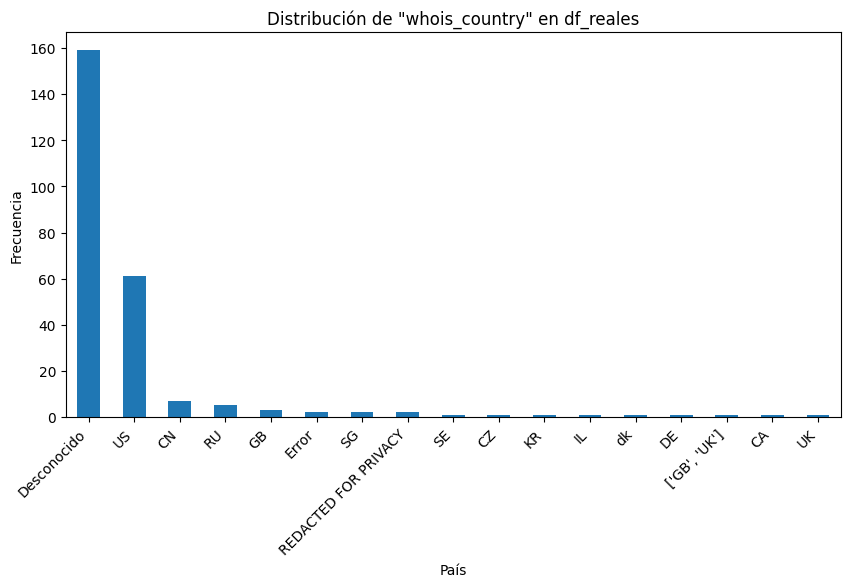

In [ ]:
for nombre, df in datasets.items():
    print(f"\nAnalizando {nombre}...")
    plt.figure(figsize=(10, 5))
    df['whois_country'].value_counts().plot(kind='bar')
    plt.title(f'Distribución de "whois_country" en {nombre}')
    plt.xlabel('País')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.show()


Analizando df_reales...


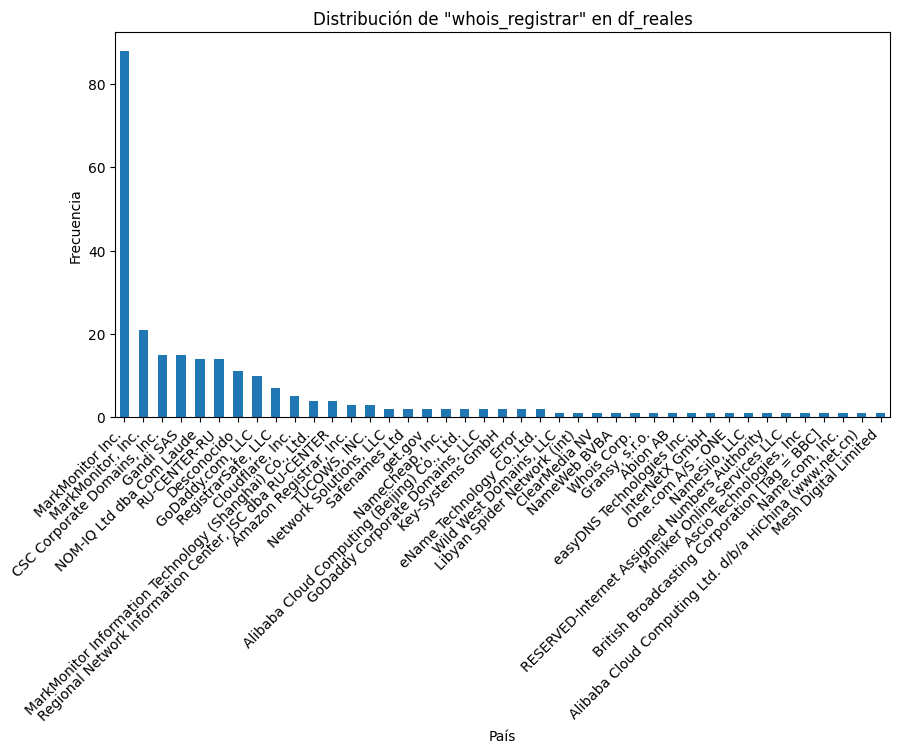

In [ ]:
for nombre, df in datasets.items():
    print(f"\nAnalizando {nombre}...")
    plt.figure(figsize=(10, 5))
    df['whois_registrar'].value_counts().plot(kind='bar')
    plt.title(f'Distribución de "whois_registrar" en {nombre}')
    plt.xlabel('País')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.show()

Observaciones:
1. Valores "Desconocido": este valor podria ser un potencial indicador de sitios phisinig, ya que indica que el servidor del dominio podria haber configurado privacidad para dicha informacion, lo que podria ser una medida para dificultar rastreo de origen. Por lo que se decide no eliminar dicho dato.
2. Valores "Error": este valor se origina debido a algun error en la solicitud. Debido a que el dataset de datos reales es el que se empleara para entrenamiento y que este posee un porcentaje reducido de datos con dicho valor, es que se opta por filtrar dichos valores.

In [ ]:
# Crear un nuevo DataFrame eliminando las filas con "Error"
df_reales_cleaned = df_reales[(df_reales['whois_country'] != 'Error') & (df_reales['whois_registrar'] != 'Error')]

# Mostrar la cantidad de filas antes y después de la limpieza
print(f"Filas en df_reales: {len(df_reales)}")
print(f"Filas en df_reales_cleaned: {len(df_reales_cleaned)}")

# Calcular y mostrar la cantidad y porcentaje de registros eliminados
registros_eliminados = len(df_reales) - len(df_reales_cleaned)
porcentaje_eliminado = (registros_eliminados / len(df_reales)) * 100
print(f"Registros eliminados: {registros_eliminados}")
print(f"Porcentaje de registros eliminados: {porcentaje_eliminado:.2f}%")

Filas en df_reales: 250
Filas en df_reales_cleaned: 248
Registros eliminados: 2
Porcentaje de registros eliminados: 0.80%


##### Análisis de Valores Ceros

In [ ]:
df_reales_cleaned[df_reales_cleaned == 0].count(axis=0)

,0
domain,0
tld,0
is_https,248
url_length,0
num_hyphens,224
num_digits,237
num_special_chars,248
num_path_segments,248
has_ssl,107
whois_registrar,0


Observaciones sobre variables con valores cero:
1. is_https: variable tipo entera que puede tomar 0 o 1 (False o True)
2. num_hyphens: variable de conteo de guiones. Una url puede no tener guiones.
3. num_digits: variable de conteo de dígitos. Una url puede no tener dígitos.
4. num_special_chars: variable de conteo de caracteres especiales. Una url puede no tener caracteres especiales.
5. has_ssl: variable tipo entera que puede tomar 0 o 1 (False o True)
6. is_phishing: variable tipo entera que puede tomar 0 o 1 (False o True)

##### Análisis eliminacion de datos.

###### Análisis datos duplicados

Se analizará solamente la columna "domain" para todos los datasets, ya que: esta columna identifica cada registro y las demás columnas son descripciones de esta columna.

In [ ]:
# Obtenemos la cantidad de valores únicos en la columna 'domain'
num_dominios_unicos = df_reales['domain'].nunique()

# Obtenemos el número total de registros en el dataframe
total_registros = len(df_reales)

print(f"Número de dominios únicos: {num_dominios_unicos}")
print(f"Número total de registros: {total_registros}")

# Verificamos si el número de dominios únicos es menor que el número total de registros
if num_dominios_unicos < total_registros:
    print("\nExisten registros duplicados en la columna 'domain'.")
else:
    print("\nNo se encontraron registros duplicados en la columna 'domain'.")

Número de dominios únicos: 250
Número total de registros: 250

No se encontraron registros duplicados en la columna 'domain'.


In [ ]:
# Obtenemos la cantidad de valores únicos en la columna 'domain'
num_dominios_unicos = df_argendir['domain'].nunique()

# Obtenemos el número total de registros en el dataframe
total_registros = len(df_argendir)

print(f"Número de dominios únicos: {num_dominios_unicos}")
print(f"Número total de registros: {total_registros}")

# Verificamos si el número de dominios únicos es menor que el número total de registros
if num_dominios_unicos < total_registros:
    print("\nExisten registros duplicados en la columna 'domain'.")
else:
    print("\nNo se encontraron registros duplicados en la columna 'domain'.")

Número de dominios únicos: 60
Número total de registros: 60

No se encontraron registros duplicados en la columna 'domain'.


In [ ]:
# Obtenemos la cantidad de valores únicos en la columna 'domain'
num_dominios_unicos = df_sintetico['domain'].nunique()

# Obtenemos el número total de registros en el dataframe
total_registros = len(df_sintetico)

print(f"Número de dominios únicos: {num_dominios_unicos}")
print(f"Número total de registros: {total_registros}")

# Verificamos si el número de dominios únicos es menor que el número total de registros
if num_dominios_unicos < total_registros:
    print("\nExisten registros duplicados en la columna 'domain'.")
    print(f"Porcentaje Datos Duplicados: {(total_registros-num_dominios_unicos)/total_registros * 100 :.2f} %")
else:
    print("\nNo se encontraron registros duplicados en la columna 'domain'.")

Número de dominios únicos: 4361
Número total de registros: 5000

Existen registros duplicados en la columna 'domain'.
Porcentaje Datos Duplicados: 12.78 %


* Observaciones:
  * Existen valores duplicados de dominios para el dataset con datos sintéticos. Se observa que el valor es cercano al 13%.

  * Solución: se propone como estrategia remover y generar nuevamente los datos hasta obtener datos con dominios únicos. Debido a que la generación de datos es controlado por el proyecto mismo, dicha lógica podria añadirse a la etapa de generación de datos sintéticos.

###### Análisis datos outliers

Se analizarán solamente los datasets con sitios web reales y sitios phishing, ya que los datos sintéticos deberían simular las distribuciones de datos reales.

###### Columna "tld"

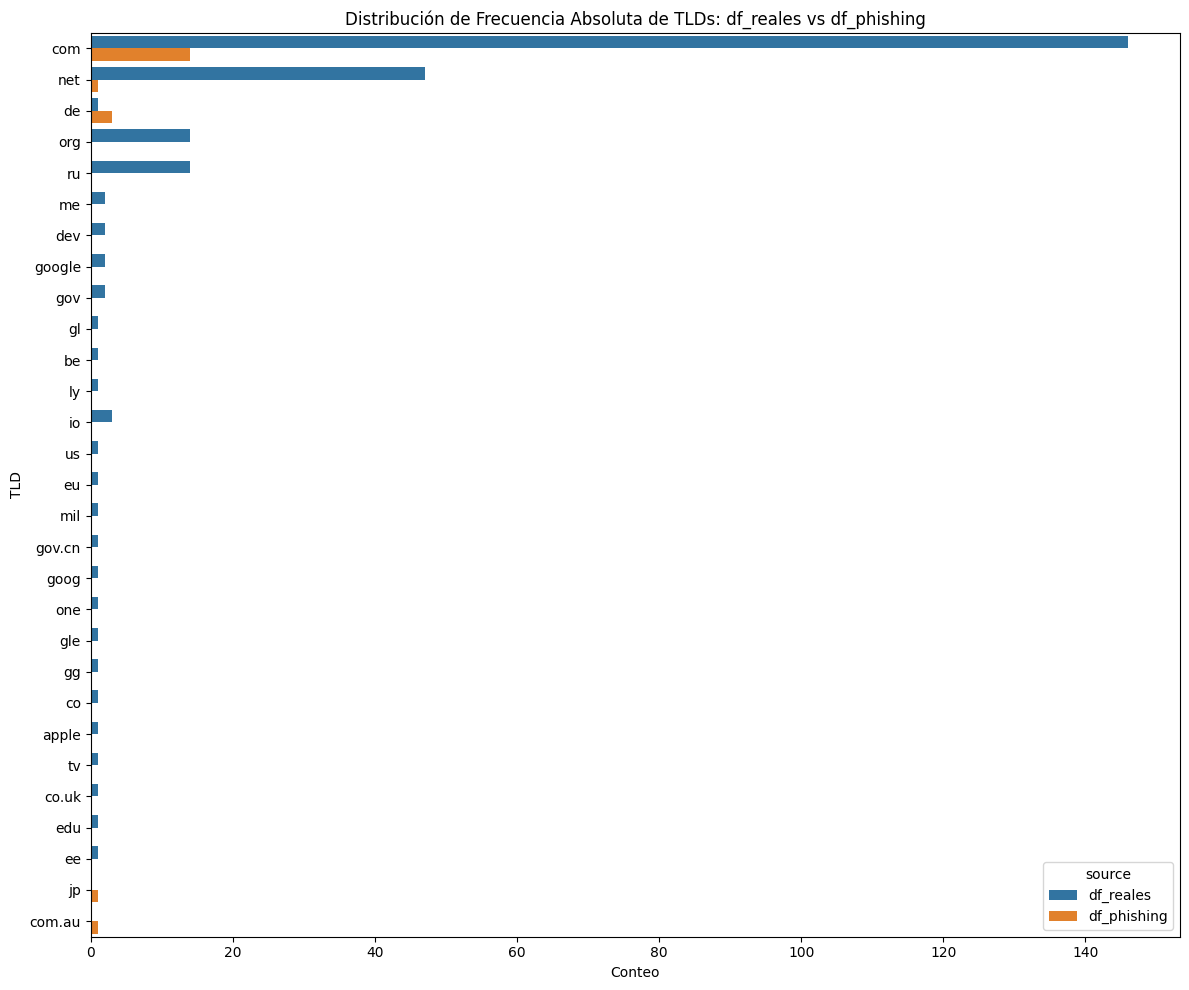

In [ ]:
# Calculamos las frecuencias absolutas para cada dataframe
tld_counts_reales = df_reales['tld'].value_counts().reset_index()
tld_counts_reales.columns = ['tld', 'count']
tld_counts_reales['source'] = 'df_reales'

tld_counts_phishing = df_phishing['tld'].value_counts().reset_index()
tld_counts_phishing.columns = ['tld', 'count']
tld_counts_phishing['source'] = 'df_phishing'

# Combinamos los dataframes de conteo
df_tld_count_combined = pd.concat([tld_counts_reales, tld_counts_phishing])

# Obtuvimos el orden de los TLDs basado en la frecuencia general para una mejor visualización
tld_order_count = df_tld_count_combined['tld'].value_counts().index

# Creamos un gráfico de barras agrupado para la distribución de frecuencia absoluta
plt.figure(figsize=(12, 10)) # Ajustamos el tamaño de la figura según fue necesario
sns.barplot(data=df_tld_count_combined, x='count', y='tld', hue='source', order=tld_order_count)
plt.title('Distribución de Frecuencia Absoluta de TLDs: df_reales vs df_phishing')
plt.xlabel('Conteo')
plt.ylabel('TLD')
plt.tight_layout()
plt.show()

In [ ]:
FILTER_RELATIVE_FREQ = 0.02
# Calculamos la frecuencia relativa de los TLDs en df_reales
tld_frequencies_reales = df_reales['tld'].value_counts(normalize=True)

# Obtuvimos la lista de TLDs con frecuencia relativa <= FILTER_RELATIVE_FREQ en df_reales
tlds_to_remove_reales = tld_frequencies_reales[tld_frequencies_reales <= FILTER_RELATIVE_FREQ].index.tolist()

print(f"TLDs con frecuencia relativa <= {FILTER_RELATIVE_FREQ*100}% en df_reales:")
print(tlds_to_remove_reales)

# Calculamos la frecuencia relativa de los TLDs en df_phishing
tld_frequencies_phishing = df_phishing['tld'].value_counts(normalize=True)

# Obtuvimos la lista de TLDs con frecuencia relativa <= FILTER_RELATIVE_FREQ en df_phishing
tlds_to_remove_phishing = tld_frequencies_phishing[tld_frequencies_phishing <=FILTER_RELATIVE_FREQ].index.tolist()

print(f"\nTLDs con frecuencia relativa <= {FILTER_RELATIVE_FREQ*100}% en df_phishing:")
print(tlds_to_remove_phishing)

TLDs con frecuencia relativa <= 2.0% en df_reales:
['io', 'me', 'dev', 'google', 'gov', 'gl', 'be', 'ly', 'us', 'de', 'eu', 'mil', 'gov.cn', 'goog', 'one', 'gle', 'gg', 'co', 'apple', 'tv', 'co.uk', 'edu', 'ee']

TLDs con frecuencia relativa <= 2.0% en df_phishing:
[]


In [ ]:
# Filtramos las frecuencias basadas en los TLDs
filtered_frequencies = tld_frequencies_reales[~tld_frequencies_reales.index.isin(tlds_to_remove_reales)]

In [ ]:
# Filtramos las frecuencias basadas en los TLDs
filtered_frequencies = tld_frequencies_phishing[~tld_frequencies_phishing.index.isin(tlds_to_remove_frequencies_phishing)]

###### Columna "url_lenght"

In [ ]:
column_selected = "url_length"

# Lista de datasets a graficar (excluyendo df_sintetico para esta comparación específica 2x2)
datasets_to_plot = [
    (df_reales, "violet", "df_reales"),
    (df_phishing, "orange", "df_phishing"),
    # (df_sintetico, "blue", "df_sintetico") # Excluido para esta comparación 2x2
]

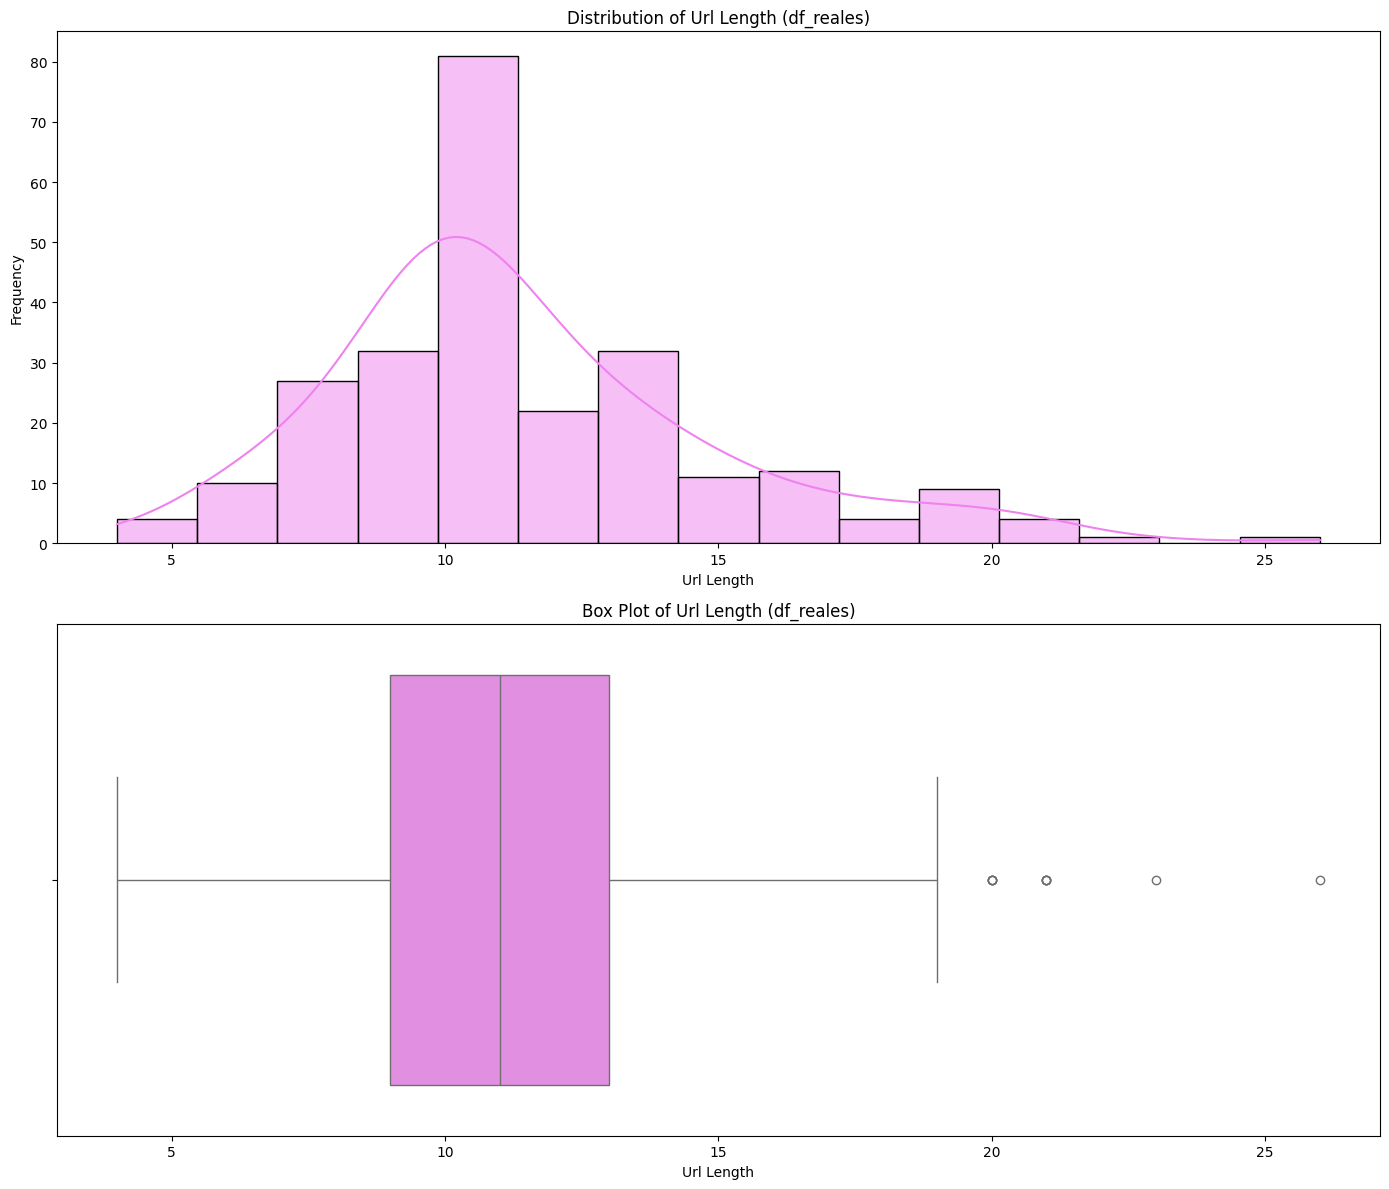

In [ ]:
# Lista de columnas a graficar
columns_to_plot = ["url_length"]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Aplanamos el array de ejes para una fácil indexación
axes = axes.flatten()

# Iteramos sobre columnas y datasets para poblar los subplots
for i, column_selected in enumerate(columns_to_plot):
    column_title = column_selected.replace('_',' ').title()

    # Graficamos histograma para df_reales en la primera fila (índice 0 o 1)
    sns.histplot(data=datasets_to_plot[0][0], x=column_selected, kde=True, color=datasets_to_plot[0][1], bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {column_title} ({datasets_to_plot[0][2]})')
    axes[i].set_xlabel(column_title)
    axes[i].set_ylabel('Frequency')

    # Graficamos boxplot para df_reales en la segunda fila (índice 2 o 3)
    sns.boxplot(data=datasets_to_plot[0][0], x=column_selected, color=datasets_to_plot[0][1], ax=axes[i + len(columns_to_plot)])
    axes[i + len(columns_to_plot)].set_title(f'Box Plot of {column_title} ({datasets_to_plot[0][2]})')
    axes[i + len(columns_to_plot)].set_xlabel(column_title)


plt.tight_layout() # Ajustamos el diseño para evitar superposición de etiquetas
plt.show()

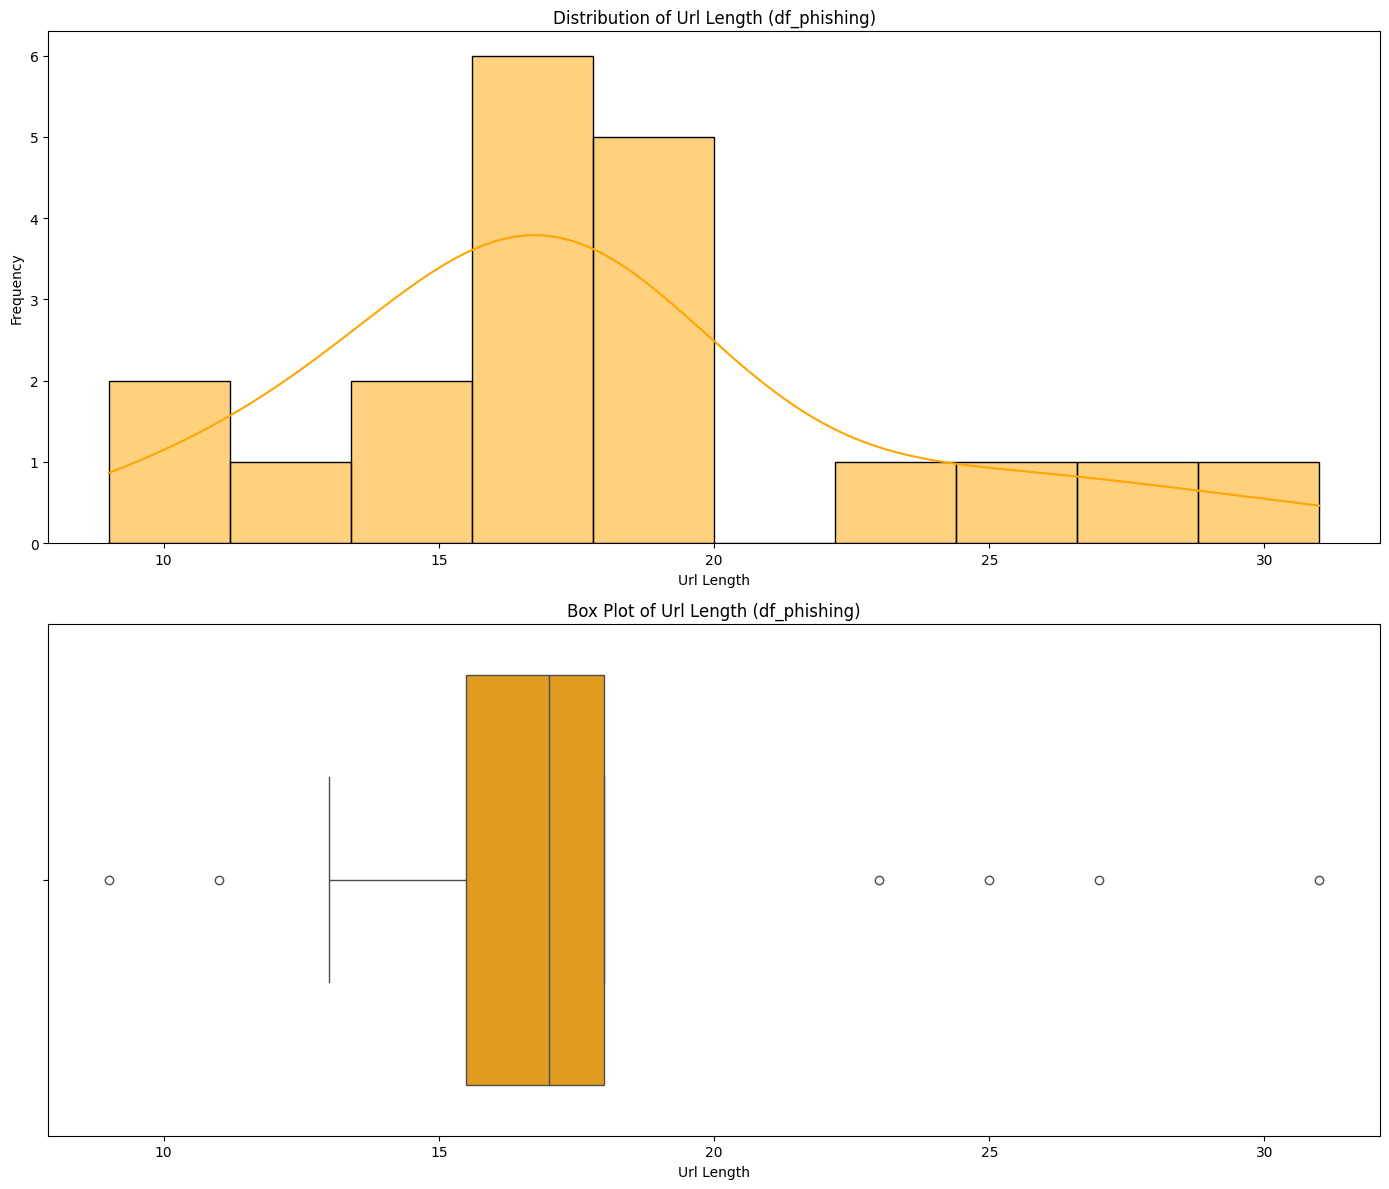

In [ ]:
# Lista de columnas a graficar
columns_to_plot = ["url_length"]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Aplanamos el array de ejes para una fácil indexación
axes = axes.flatten()

# Iteramos sobre columnas y datasets para poblar los subplots
for i, column_selected in enumerate(columns_to_plot):
    column_title = column_selected.replace('_',' ').title()

    # Graficamos histograma para df_phishing en la primera fila (índice 0 o 1)
    sns.histplot(data=datasets_to_plot[1][0], x=column_selected, kde=True, color=datasets_to_plot[1][1], bins=10, ax=axes[i])
    axes[i].set_title(f'Distribution of {column_title} ({datasets_to_plot[1][2]})')
    axes[i].set_xlabel(column_title)
    axes[i].set_ylabel('Frequency')

    # Graficamos boxplot para df_phishing en la segunda fila (índice 2 o 3)
    sns.boxplot(data=datasets_to_plot[1][0], x=column_selected, color=datasets_to_plot[1][1], ax=axes[i + len(columns_to_plot)])
    axes[i + len(columns_to_plot)].set_title(f'Box Plot of {column_title} ({datasets_to_plot[1][2]})')
    axes[i + len(columns_to_plot)].set_xlabel(column_title)


plt.tight_layout() # Ajustamos el diseño para evitar superposición de etiquetas
plt.show()

Observaciones:  
1. Para el dataset sitios web reales, se observa una distribución con cola derecha extendida y poseen 4 valores outliers intermedios (no mayor a Q3 + 3.IQR).
2. Para el dataset sitios web phishing, se observa una distribución de cola derecha, con 6 valores outliers.

Filtrado: para el 1er dataset se plantea un filtrado con IQR, mientras que para el 2do se plantea un filtrado de percentil.

In [ ]:
def get_data_filtered_by_IQR(df, column):
  # Calculamos Q1, Q3 e IQR
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  # Definimos el límite superior para la detección de outliers (Q3 + 1.5 * IQR)
  upper_bound = Q3 + 1.5 * IQR

  # Filtramos los outliers por encima del límite superior
  return df[df[column] <= upper_bound].copy()


def get_data_filtered_by_percentil(df, column, quantile):
  # Calculamos el límite superior del cuantil
  upper_bound = df[column].quantile(quantile)

  # Filtramos los outliers por encima del límite superior
  return df[df[column] <= upper_bound].copy()


def apply_filter(df, dataset_name, filter, column, *args):
  # Filtramos los outliers por encima del límite superior
  df_filtered = filter(df, column, *args)

  # Calculamos el porcentaje de datos filtrados
  original_rows = len(df)
  filtered_rows = len(df_filtered)
  percentage_filtered = ((original_rows - filtered_rows) / original_rows) * 100

  print("-"*40)
  print(f"Dataset '{dataset_name}'")
  print(f"Número original de filas: {original_rows}")
  print(f"Número de filas después de filtrar outliers: {filtered_rows}")
  print(f"Porcentaje de datos filtrados: {percentage_filtered:.2f}%")

  return df_filtered

In [ ]:
df_reales_filtered = apply_filter(df_reales, "Dataset Sitios Reales", get_data_filtered_by_IQR, column_selected)
df_phishing_filtered = apply_filter(df_phishing, "Dataset Sitios Phishing", get_data_filtered_by_percentil, column_selected, 0.95)

----------------------------------------
Dataset 'Dataset Sitios Reales'
Número original de filas: 250
Número de filas después de filtrar outliers: 240
Porcentaje de datos filtrados: 4.00%
----------------------------------------
Dataset 'Dataset Sitios Phishing'
Número original de filas: 20
Número de filas después de filtrar outliers: 19
Porcentaje de datos filtrados: 5.00%


###### Columna "domain_age_days"

In [ ]:
column_selected = "domain_age_days"
selected_dataset = df_reales
display_color = "blue"

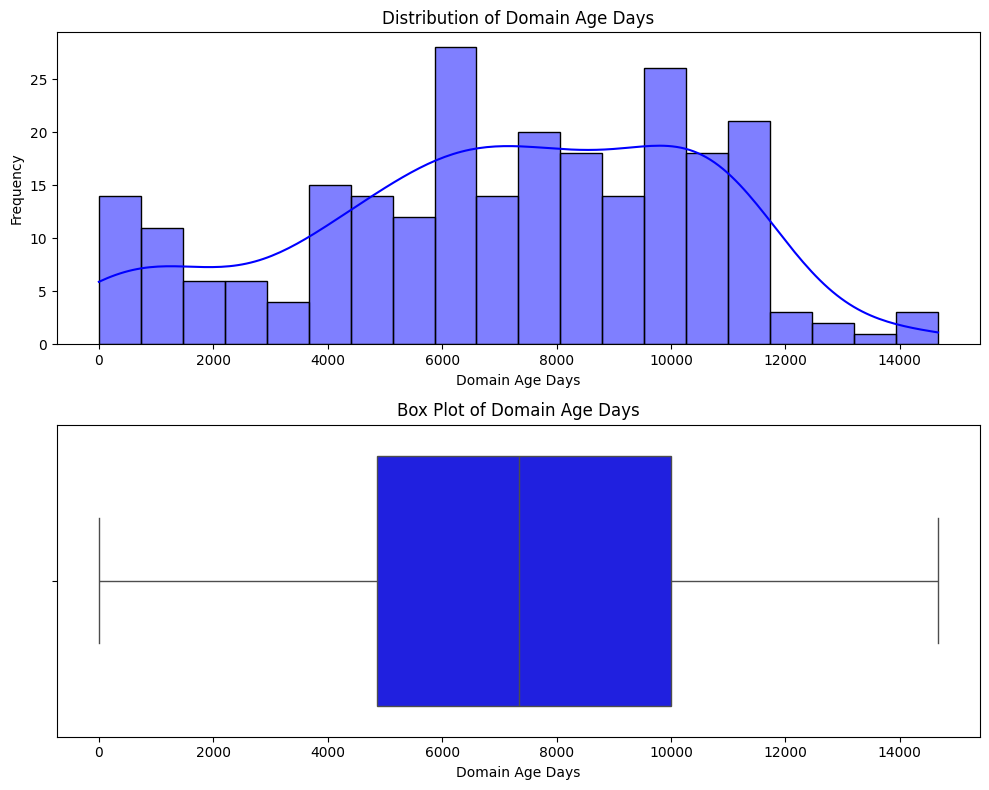

In [ ]:
# Creamos una figura con dos subplots para df_reales
plt.figure(figsize=(10, 8))

column_title = column_selected.replace('_',' ').title()

# Histograma
plt.subplot(2, 1, 1)
sns.histplot(data=selected_dataset, x=column_selected, kde=True, color=display_color,bins=20)
plt.title(f'Distribution of {column_title}')
plt.xlabel(column_title)
plt.ylabel('Frequency')

# Boxplot
plt.subplot(2, 1, 2)
sns.boxplot(data=selected_dataset, x=column_selected, color=display_color)
plt.title(f'Box Plot of {column_title}')
plt.xlabel(f"{column_title}")

plt.tight_layout() # Ajustamos el diseño para evitar superposición de etiquetas
plt.show()

Observaciones:
1. Se observa una distribucion bimodal, No normal.

Filtrado: no se plantea realizar un filtrado, pero en caso de ser una variable de interés, a futuro se podría pensar en forzar a convertir en una distribución normal.

### 3. Generacion Dataset Maestro

El proyecto continúa delineando el camino a seguir para operacionalizar el sistema de detección. En esta etapa se pretende realizar la **Generación de un Dataset Maestro**, el cual busca consolidar los datasets ya limpios y estructurados, en un único dataset maestro listo para el análisis.

Puntos a considerar:
  - Para la generacion del dataset maestro se debio generar:
    * Generar nuevamente el dataset sitios web reales de Tranco para **4000** registros.
    * Generar nuevamente el dataset con sitios web phishing de Kaggle para **2000** registros.  

 **Obs**: *Esto se debio realizar mediante una ejecucion local debido a las limitaciones en las sesiones de ejecucion desde Google Collab.*
  - En esta instancia se opto por no enriquecer empleando datos sinteticos. En un futuro se contempla ampliar el dataset mediante dicho enriquecimiento.
  - Realizamos una limpieza final: homogeneizamos tipos de datos (`is_phishing` a `int`), gestionamos valores "Error" en columnas WHOIS (ej., imputación o considerarlos como una categoría separada).


In [ ]:
PATH_DATASET_SITIOS_WEB_REALES_FINAL = "dataset_sitios_reales_final.csv"
PATH_DATASET_SITIOS_PHISHING_FINAL = "dataset_phishing_final.csv"

df_reales_final = pd.read_csv(PATH_DATASET_SITIOS_WEB_REALES_FINAL)
df_phishing_final = pd.read_csv(PATH_DATASET_SITIOS_PHISHING_FINAL)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_sitios_reales_final.csv'

In [ ]:
##################################################################
#  Concatenamos todos los DataFrames
df_master = pd.concat([df_reales_final, df_phishing_final], ignore_index=True)
##################################################################

# Mostramos información del DataFrame maestro para verificar la unión
print("Información del DataFrame Maestro:")
df_master.info()

print("\nPrimeras 5 filas del DataFrame Maestro:")
display(df_master.head())

print("\nÚltimas 5 filas del DataFrame Maestro (para ver los datos de Kaggle):")
display(df_master.tail())

NameError: name 'df_reales_final' is not defined

In [ ]:
# Gestionamos los valores "Error" en las columnas WHOIS
# Reemplazamos "Error" con NaN y reasignamos para evitar el FutureWarning
df_master['whois_registrar'] = df_master['whois_registrar'].replace('Error', np.nan)
df_master['whois_country'] = df_master['whois_country'].replace('Error', np.nan)
df_master['domain_age_days'] = df_master['domain_age_days'].replace(-1, np.nan)


# Verificamos los cambios
print("Información del DataFrame Maestro después de la limpieza:")
df_master.info()

print("\nConteo de valores en 'whois_country' para verificar la eliminación de 'Error':")
print(df_master['whois_country'].value_counts(dropna=False).head())

print("\nPrimeras 5 filas del DataFrame Maestro limpio:")
display(df_master.head())

Información del DataFrame Maestro después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             6000 non-null   object 
 1   tld                6000 non-null   object 
 2   is_https           6000 non-null   int64  
 3   url_length         6000 non-null   int64  
 4   num_hyphens        6000 non-null   int64  
 5   num_digits         6000 non-null   int64  
 6   num_special_chars  6000 non-null   int64  
 7   num_path_segments  6000 non-null   int64  
 8   has_ssl            6000 non-null   int64  
 9   whois_registrar    4847 non-null   object 
 10  whois_country      4847 non-null   object 
 11  domain_age_days    4411 non-null   float64
 12  is_phishing        6000 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 609.5+ KB

Conteo de valores en 'whois_country' para verifica

,domain,tld,is_https,url_length,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl,whois_registrar,whois_country,domain_age_days,is_phishing
0,skokka.com,com,0,10,0,0,0,0,0,NaN,NaN,NaN,0
1,forter.com,com,0,10,0,0,0,0,0,NaN,NaN,NaN,0
2,xosodaiphat.com,com,0,15,0,0,0,0,0,NaN,NaN,NaN,0
3,geeksforgeeks.org,org,0,17,0,0,0,0,0,PDR Ltd. d/b/a PublicDomainRegistry.com,US,5974.0,0
4,humeysha.com,com,0,12,0,0,0,0,0,DropCatch.com 1066 LLC,US,762.0,0


In [ ]:
df_master.to_csv("dataset_maestro.csv", index=False)

### 4. Análisis de Correlación:
Para este analisis se planteo:
  - Calcular una matriz de correlación (`df_master.corr()`) en las características numéricas para identificar multicolinealidad.  
  - Utilizar técnicas como el V de Cramer o Phik para analizar la correlación entre variables categóricas.


Matriz de Correlación de Pearson para variables numéricas:


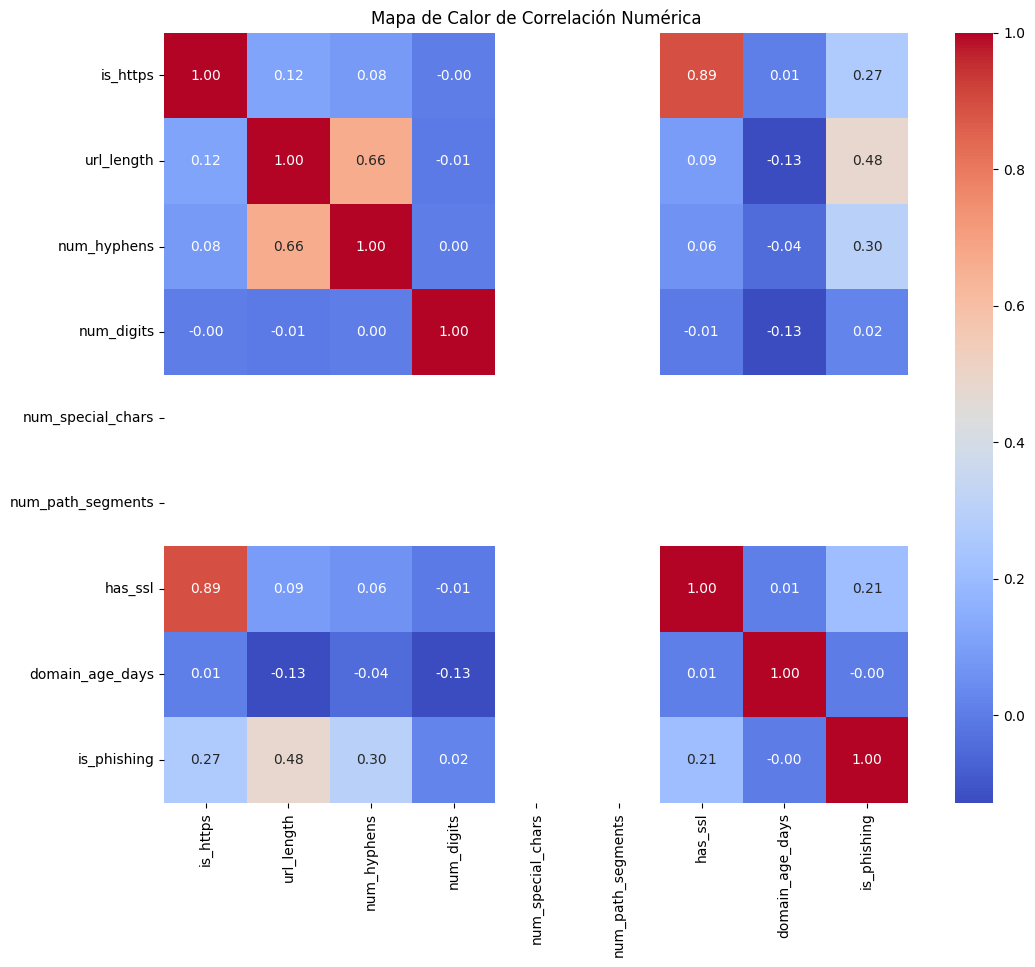

,is_https,url_length,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl,domain_age_days,is_phishing
is_https,1.000000,0.117051,0.083971,-0.000044,NaN,NaN,0.892740,0.007078,0.265990
url_length,0.117051,1.000000,0.662085,-0.008567,NaN,NaN,0.090308,-0.126367,0.480492
num_hyphens,0.083971,0.662085,1.000000,0.002551,NaN,NaN,0.064608,-0.044592,0.295750
num_digits,-0.000044,-0.008567,0.002551,1.000000,NaN,NaN,-0.009044,-0.128186,0.020251
num_special_chars,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_path_segments,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_ssl,0.892740,0.090308,0.064608,-0.009044,NaN,NaN,1.000000,0.005084,0.210316
domain_age_days,0.007078,-0.126367,-0.044592,-0.128186,NaN,NaN,0.005084,1.000000,-0.002708
is_phishing,0.265990,0.480492,0.295750,0.020251,NaN,NaN,0.210316,-0.002708,1.000000


In [ ]:
# Análisis de Correlación Numérica
print("Matriz de Correlación de Pearson para variables numéricas:")
# Seleccionamos solo las columnas numéricas para la correlación
numerical_cols = df_master.select_dtypes(include=np.number).columns
correlation_matrix = df_master[numerical_cols].corr()

# Visualizamos la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación Numérica')
plt.show()

display(correlation_matrix)

A continuación, procederemos con el análisis de las variables categóricas usando Phik.

In [ ]:
# Análisis de Correlación Categórica con Phik
# Instalamos la librería phik
!pip install phik

import phik
from phik.report import plot_correlation_matrix

print("\nMatriz de Correlación Phik para todas las variables (incluyendo categóricas):")

# Calculamos la matriz de correlación Phik
# Phik puede manejar una mezcla de tipos de datos
phik_matrix = df_master.phik_matrix()

# Visualizamos la matriz de correlación Phik
plot_correlation_matrix(phik_matrix.values,
                        x_labels=phik_matrix.columns,
                        y_labels=phik_matrix.index,
                        vmin=0, vmax=1,
                        title="Matriz de Correlación Phik",
                        figsize=(15, 12))

display(phik_matrix)

 ### Próximos Pasos y Refinamientos de Preprocesamiento
 1. **Automatización con Airflow y BigQuery:**
    - **BigQuery:** Servirá como Data Warehouse para almacenar el dataset maestro. Esto permite consultas eficientes y desacopla el almacenamiento de datos del entorno de ejecución.
    - **Airflow:** Se diseñará un DAG (Grafo Acíclico Dirigido) que orqueste todo el pipeline:
        - Tareas para descargar/scrapear los datos de las fuentes.
        - Tareas para aplicar los scripts de limpieza y transformación de datos.
        - Una tarea final para cargar (o actualizar) el dataset maestro en la tabla de BigQuery.

2. **Seleccion de variables de interes para el entrenamiento**: se observaron que ciertas variables de entrada son redundantes en informacion (debido a su correlacion) y que no existen grados fuertes de correlacion lineal con la variable a predecir.

3. **Analisis y Enriquecimiento con datos sinteticos**



## 📈 Entregable 3: Análisis Supervisado y No Supervisado

**Valor de esta etapa:** Una vez que tenemos datos limpios y enriquecidos, el siguiente paso es construir la "inteligencia" de nuestro sistema. En esta fase, exploraremos diferentes técnicas de Machine Learning para **construir modelos que puedan aprender a distinguir automáticamente entre sitios web legítimos y fraudulentos**. Utilizaremos tanto enfoques supervisados (donde el modelo aprende de ejemplos etiquetados de sitios fraudulentos) como no supervisados (donde el modelo busca patrones en los datos sin etiquetas explícitas).

### Objetivos

Para este entregable, se proponen los siguientes objetivos:

1.  **Análisis Supervisado:**
    *   Seleccionar y entrenar modelos de clasificación (por ejemplo, Regresión Logística, Árboles de Decisión, Random Forest, SVM, etc.) utilizando el dataset maestro etiquetado.
    *   Evaluar el rendimiento de los modelos utilizando métricas apropiadas para problemas de clasificación desbalanceados (por ejemplo, Precisión, Recall, F1-Score, Área bajo la curva ROC).
    *   Realizar ajuste de hiperparámetros para optimizar el rendimiento de los modelos.
2.  **Análisis No Supervisado:**
    *   Aplicar técnicas de clustering (por ejemplo, K-Means, DBSCAN) sobre las características de los sitios web para identificar grupos naturales (clusters) de sitios.
    *   Analizar si los clusters identificados se corresponden con la etiqueta de `is_phishing`, lo que podría indicar patrones latentes que las técnicas supervisadas podrían explotar.
    *   Explorar técnicas de detección de anomalías para identificar sitios que se desvían significativamente de los patrones esperados de los sitios legítimos.
3.  **Selección del Modelo Final:**
    *   Comparar los resultados de los modelos supervisados y no supervisados.
    *   Seleccionar el modelo o combinación de modelos más prometedor para la detección de sitios fraudulentos, considerando tanto el rendimiento como la interpretabilidad.

### 3.1. Análisis Supervisado: Modelado de Clasificación

#### Importacion de librerias

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import requests

#### Carga del Dataset Maestro

In [ ]:
# URL del archivo CSV en GitHub (raw content)
csv_github_url = "https://raw.githubusercontent.com/mirhughes/diplo/main/dataset_maestro.csv"
local_csv_filename = "dataset_maestro.csv"
df_master = local_csv_filename

try:
    # Descargar el contenido del archivo CSV
    response = requests.get(csv_github_url)
    response.raise_for_status() # Lanza un error para códigos de estado HTTP incorrectos

    # Guardar el contenido en un archivo local
    with open(local_csv_filename, 'w', encoding='utf-8') as f:
        f.write(response.text)

    print(f"✅ Archivo descargado y guardado como: '{local_csv_filename}'")

    # Cargar el dataset maestro desde el archivo local
    df_master = pd.read_csv(local_csv_filename)
except requests.exceptions.RequestException as e:
    print(f"❌ Error al descargar el archivo CSV: {e}")
except FileNotFoundError:
    print(f"❌ Error: El archivo '{local_csv_filename}' no se encontró después de la descarga.")
except Exception as e:
    print(f"❌ Ocurrió un error: {e}")

✅ Archivo descargado y guardado como: 'dataset_maestro.csv'


In [ ]:

# Mostrar las primeras filas y la información del DataFrame
print("Información del DataFrame Maestro:")
df_master.info()

print("\nPrimeras 5 filas del DataFrame Maestro:")
display(df_master.head())

Información del DataFrame Maestro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             6000 non-null   object 
 1   tld                6000 non-null   object 
 2   is_https           6000 non-null   int64  
 3   url_length         6000 non-null   int64  
 4   num_hyphens        6000 non-null   int64  
 5   num_digits         6000 non-null   int64  
 6   num_special_chars  6000 non-null   int64  
 7   num_path_segments  6000 non-null   int64  
 8   has_ssl            6000 non-null   int64  
 9   whois_registrar    4847 non-null   object 
 10  whois_country      4847 non-null   object 
 11  domain_age_days    4411 non-null   float64
 12  is_phishing        6000 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 609.5+ KB

Primeras 5 filas del DataFrame Maestro:


,domain,tld,is_https,url_length,num_hyphens,num_digits,num_special_chars,num_path_segments,has_ssl,whois_registrar,whois_country,domain_age_days,is_phishing
0,skokka.com,com,0,10,0,0,0,0,0,NaN,NaN,NaN,0
1,forter.com,com,0,10,0,0,0,0,0,NaN,NaN,NaN,0
2,xosodaiphat.com,com,0,15,0,0,0,0,0,NaN,NaN,NaN,0
3,geeksforgeeks.org,org,0,17,0,0,0,0,0,PDR Ltd. d/b/a PublicDomainRegistry.com,US,5974.0,0
4,humeysha.com,com,0,12,0,0,0,0,0,DropCatch.com 1066 LLC,US,762.0,0


#### Preparación de Datos para Modelado Supervisado

Para el modelado supervisado, necesitamos separar las características (X) de la variable objetivo (y). También debemos manejar las variables categóricas restantes (`tld`, `whois_registrar`, `whois_country`) mediante codificación (por ejemplo, One-Hot Encoding).

In [ ]:
# Definir las características (X) y la variable objetivo (y)
X = df_master.drop(['domain', 'is_phishing'], axis=1) # Excluimos 'domain' ya que es un identificador
y = df_master['is_phishing']

# Identificar columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Crear pipelines de preprocesamiento para columnas numéricas y categóricas
# Para las columnas numéricas con valores NaN (introducidos al reemplazar 'Error' y -1) usaremos imputación
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')) # Imputar valores faltantes con la mediana
])

# Para las columnas categóricas, usaremos OneHotEncoder
# Manejamos los valores desconocidos y faltantes introducidos en la limpieza
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Imputar faltantes con una categoría 'missing'
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Ignorar categorías desconocidas durante la transformación
])

# Crear un ColumnTransformer para aplicar los pipelines a las columnas correctas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])


# Preprocessor con Escalado, especifico para SVM
numerical_pipeline_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Imputar valores faltantes con la mediana
    ('scaler', StandardScaler()) # Escalar los datos
])
preprocessor_SVM = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_svm, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Usamos stratify para mantener la proporción de clases

print("Dimensiones de los conjuntos de datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Dimensiones de los conjuntos de datos:
X_train: (4800, 11)
X_test: (1200, 11)
y_train: (4800,)
y_test: (1200,)


#### Entrenamiento y Evaluación de Modelos de Clasificación

Entrenaremos y evaluaremos algunos modelos de clasificación comunes para comparar su rendimiento en la detección de sitios fraudulentos.

En esta etapa se evaluaran los modelos con hiperparametros por defecto, sin tunning.

In [ ]:
# Definir los modelos a evaluar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000), # Aumentamos max_iter para asegurar convergencia
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42) # probability=True para obtener probabilidades para ROC AUC
}

results = {}

# Iterar sobre los modelos, entrenarlos y evaluarlos
for model_name, model in models.items():
    print(f"Entrenando {model_name}...")

    # Crear un pipeline completo (preprocesamiento + modelo)
    if model_name == "SVM":
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor_SVM),
            ('classifier', model)
        ])
    else:
      full_pipeline = Pipeline([
          ('preprocessor', preprocessor),
          ('classifier', model)
      ])

    # Entrenar el modelo
    full_pipeline.fit(X_train, y_train)

    # Hacer predicciones
    y_pred = full_pipeline.predict(X_test)
    y_prob = full_pipeline.predict_proba(X_test)[:, 1] # Probabilidades para ROC AUC

    # Evaluar el modelo
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    class_report = classification_report(y_test, y_pred)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC AUC": roc_auc
    }

    print(f"--- Evaluación de {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(class_report)
    print("-" * 30)

Entrenando Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



--- Evaluación de Logistic Regression ---
Accuracy: 0.8533
Precision: 0.8200
Recall: 0.7175
F1-Score: 0.7653
ROC AUC: 0.9211
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       800
           1       0.82      0.72      0.77       400

    accuracy                           0.85      1200
   macro avg       0.84      0.82      0.83      1200
weighted avg       0.85      0.85      0.85      1200

------------------------------
Entrenando Decision Tree...
--- Evaluación de Decision Tree ---
Accuracy: 0.8592
Precision: 0.8031
Recall: 0.7650
F1-Score: 0.7836
ROC AUC: 0.8520
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       800
           1       0.80      0.77      0.78       400

    accuracy                           0.86      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.86      0.86      0.86      120

#### Comparación de Modelos Supervisados

Analizamos los resultados obtenidos para cada modelo y comparamos sus métricas de rendimiento.

Resumen de Resultados de Modelos de Clasificación:


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
2,Random Forest,0.880000,0.861582,0.7625,0.809019,0.945092
3,SVM,0.875000,0.851124,0.7575,0.801587,0.936991
1,Decision Tree,0.859167,0.803150,0.7650,0.783611,0.851964
0,Logistic Regression,0.853333,0.820000,0.7175,0.765333,0.921113


<Figure size 1400x800 with 0 Axes>

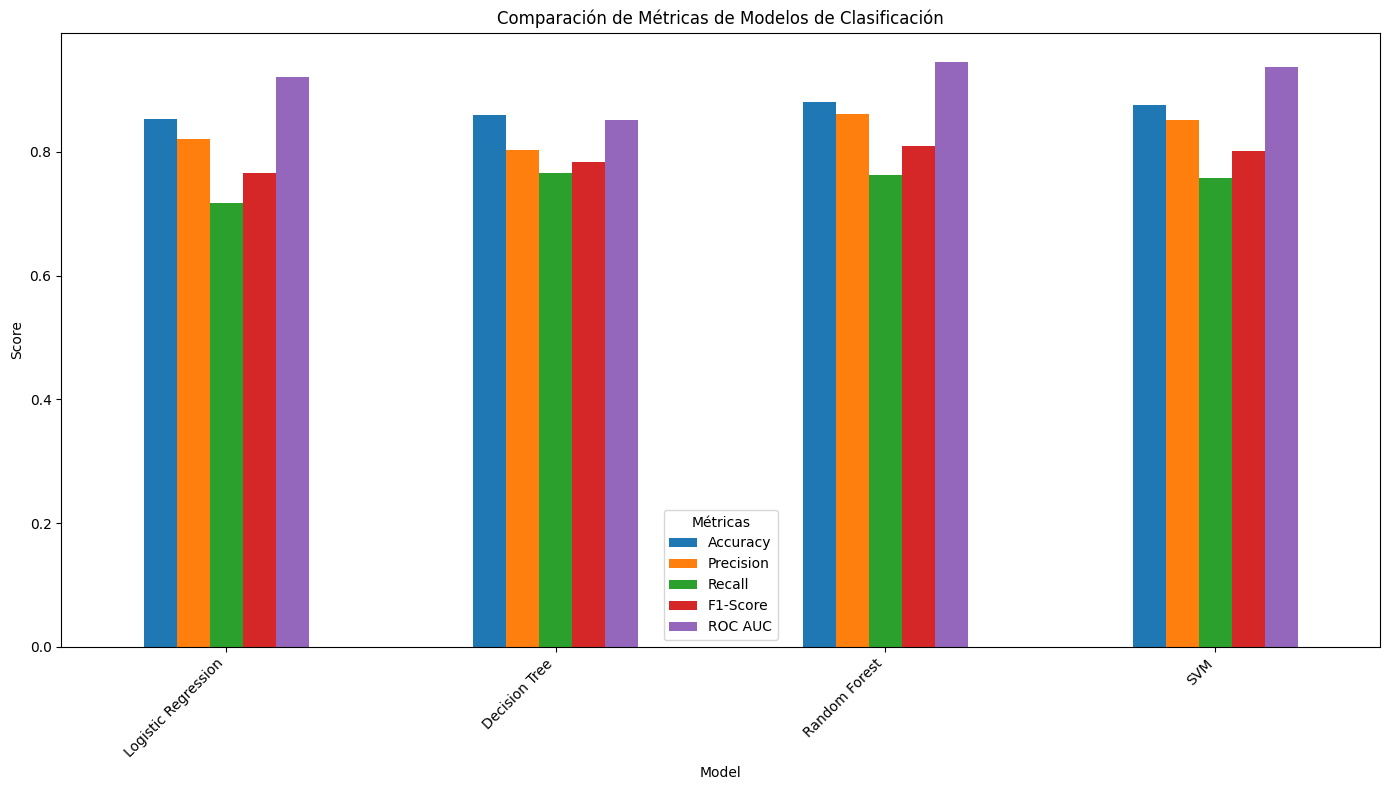

In [ ]:
# Crear un DataFrame para visualizar los resultados de las métricas clave
summary_data = []
for model_name, metrics in results.items():
    summary_data.append({
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-Score": metrics["F1-Score"],
        "ROC AUC": metrics["ROC AUC"]
    })

df_results_summary = pd.DataFrame(summary_data)

print("Resumen de Resultados de Modelos de Clasificación:")
display(df_results_summary.sort_values(by="F1-Score", ascending=False))

# Visualizar las métricas clave
plt.figure(figsize=(14, 8))
df_results_summary.set_index("Model").plot(kind='bar', figsize=(14, 8))
plt.title("Comparación de Métricas de Modelos de Clasificación")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Métricas")
plt.tight_layout()
plt.show()

#### Ajuste de Hiperparámetros

Seleccionando los 2 modelos con mayor F1-score:

1. Random Forest
2. SVM

Se realizara un ajuste de hiperparámetros utilizando GridSearchCV para optimizar uno de los modelos.

In [ ]:
# Definir el modelo y los hiperparámetros a ajustar
model_to_tune = RandomForestClassifier(random_state=42)

# Definir un espacio de búsqueda para los hiperparámetros
# Esto es solo un ejemplo, los rangos y parámetros deben ajustarse según el modelo
param_grid = {
    'classifier__n_estimators': [100, 200], # Número de árboles
    'classifier__max_depth': [None, 10, 20], # Profundidad máxima del árbol
    'classifier__min_samples_split': [2, 5, 10] # Mínimo de muestras para dividir un nodo
}

# Crear el pipeline completo con el preprocesador y el modelo a ajustar
full_pipeline_tune = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', model_to_tune)
])

# Configurar GridSearchCV
# cv: número de folds para la validación cruzada
# scoring: métrica a optimizar (ej. 'f1' para F1-Score, 'roc_auc' para ROC AUC)
# n_jobs: número de núcleos de CPU a usar (-1 para usar todos)
grid_search = GridSearchCV(full_pipeline_tune, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Realizando ajuste de hiperparámetros para Random Forest...")
# Ejecutar la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor score F1 en validación cruzada:")
print(grid_search.best_score_)

# Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

Result_tuned_RF =  {"Accuracy":  accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC AUC":   roc_auc_score(y_test, y_prob_tuned)
}

print("\n--- Evaluación del Mejor Modelo (Ajustado) en Conjunto de Prueba ---")
print(f"Accuracy: {Result_tuned_RF['Accuracy']:.4f}")
print(f"Precision: {Result_tuned_RF['Precision']:.4f}")
print(f"Recall: {Result_tuned_RF['Recall']:.4f}")
print(f"F1-Score: {Result_tuned_RF['F1-Score']:.4f}")
print(f"ROC AUC: {Result_tuned_RF['ROC AUC']:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Realizando ajuste de hiperparámetros para Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores hiperparámetros encontrados:
{'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Mejor score F1 en validación cruzada:
0.8141608141597192

--- Evaluación del Mejor Modelo (Ajustado) en Conjunto de Prueba ---
Accuracy: 0.8858
Precision: 0.8683
Recall: 0.7750
F1-Score: 0.8190
ROC AUC: 0.9497
Confusion Matrix:
[[753  47]
 [ 90 310]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       800
           1       0.87      0.78      0.82       400

    accuracy                           0.89      1200
   macro avg       0.88      0.86      0.87      1200
weighted avg       0.88      0.89      0.88      1200



Comparativa de Random Forest antes y despues de GridSearchCV


📊 Comparación de métricas (TEST):


,Antes (Base),Después (Tuned),Δ (Tuned - Base)
Recall,0.762500,0.775000,0.012500
F1-Score,0.809019,0.819022,0.010004
Precision,0.861582,0.868347,0.006765
Accuracy,0.880000,0.885833,0.005833
ROC AUC,0.945092,0.949667,0.004575


<Figure size 1200x600 with 0 Axes>

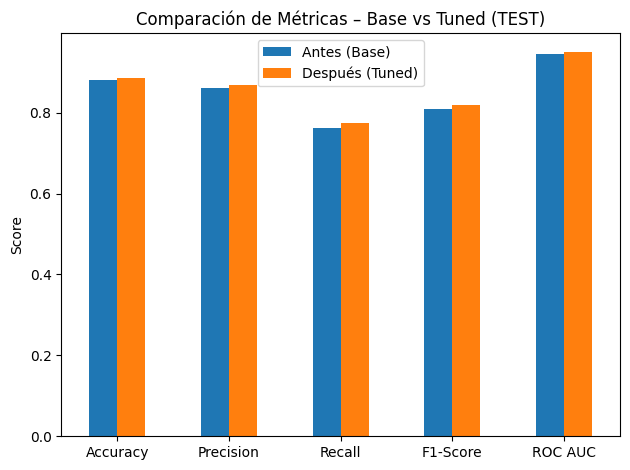

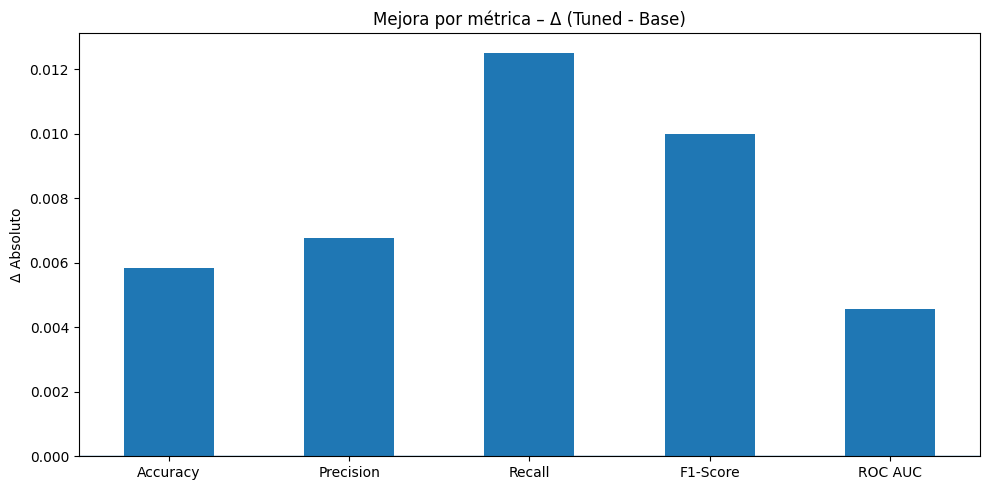

In [ ]:
df_compare = pd.DataFrame([results["Random Forest"], Result_tuned_RF], index=["Antes (Base)", "Después (Tuned)"]).T
df_compare["Δ (Tuned - Base)"] = df_compare["Después (Tuned)"] - df_compare["Antes (Base)"]

print("\n📊 Comparación de métricas (TEST):")
display(df_compare.sort_values("Δ (Tuned - Base)", ascending=False))

# Gráficos: barras comparativas y barras de Δ
# Barras comparativas
plt.figure(figsize=(12, 6))
df_compare[["Antes (Base)", "Después (Tuned)"]].plot(kind="bar")
plt.title("Comparación de Métricas – Base vs Tuned (TEST)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Barras de mejora (Δ)
plt.figure(figsize=(10, 5))
df_compare["Δ (Tuned - Base)"].plot(kind="bar")
plt.title("Mejora por métrica – Δ (Tuned - Base)")
plt.ylabel("Δ Absoluto")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


El tuning de Random Forest mejora levemente todas las métricas en test, señal de que el modelo ya estaba cerca de su óptimo; priorizaremos PR-AUC/Recall y ajuste de umbral para impacto práctico.

Aplicamos GridSearchCV tambien a SVC

In [ ]:
# Definir el modelo y los hiperparámetros a ajustar
model_to_tune = SVC(probability=True, random_state=42)

# Definir un espacio de búsqueda para los hiperparámetros
# Esto es solo un ejemplo, los rangos y parámetros deben ajustarse según el modelo
param_grid = {
    'classifier__C': [0.1, 1, 10,100], # Parametro de regularizacion
    'classifier__kernel': ["linear", "rbf", "sigmoid"], # Tipo de kernel
  #  'classifier__degree': [2,3,5] # Grado de polinomio para kernel=poly (ignorado por otros kernels)
}

# Crear el pipeline completo con el preprocesador y el modelo a ajustar
full_pipeline_tune = Pipeline([
    ('preprocessor', preprocessor_SVM),
    ('classifier', model_to_tune)
])

# Configurar GridSearchCV
# cv: número de folds para la validación cruzada
# scoring: métrica a optimizar (ej. 'f1' para F1-Score, 'roc_auc' para ROC AUC)
# n_jobs: número de núcleos de CPU a usar (-1 para usar todos)
grid_search = GridSearchCV(full_pipeline_tune, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Realizando ajuste de hiperparámetros para Support Vector Machine...")
# Ejecutar la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor score Recall en validación cruzada:")
print(grid_search.best_score_)

# Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

Result_tuned_SVC =  {"Accuracy":  accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC AUC":   roc_auc_score(y_test, y_prob_tuned)
}

print("\n--- Evaluación del Mejor Modelo (Ajustado) en Conjunto de Prueba ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Realizando ajuste de hiperparámetros para Support Vector Machine...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores hiperparámetros encontrados:
{'classifier__C': 10, 'classifier__kernel': 'rbf'}

Mejor score Recall en validación cruzada:
0.818196537464058

--- Evaluación del Mejor Modelo (Ajustado) en Conjunto de Prueba ---
Accuracy: 0.8833
Precision: 0.8385
Recall: 0.8050
F1-Score: 0.8214
ROC AUC: 0.9454
Confusion Matrix:
[[738  62]
 [ 78 322]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       800
           1       0.84      0.81      0.82       400

    accuracy                           0.88      1200
   macro avg       0.87      0.86      0.87      1200
weighted avg       0.88      0.88      0.88      1200



Comparamos SVC antes y despues de GridSearchCV


📊 Comparación de métricas (TEST):


,Antes (Base SVM),Después (SVM Tuned),Δ (Tuned - Base)
Recall,0.757500,0.805000,0.047500
F1-Score,0.801587,0.821429,0.019841
ROC AUC,0.936991,0.945369,0.008378
Accuracy,0.875000,0.883333,0.008333
Precision,0.851124,0.838542,-0.012582


<Figure size 1200x600 with 0 Axes>

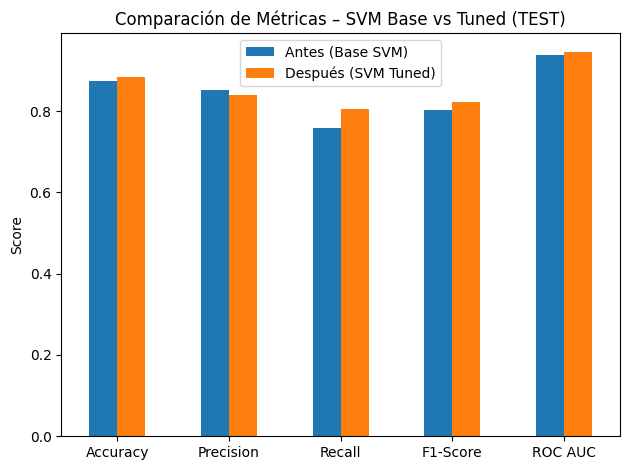

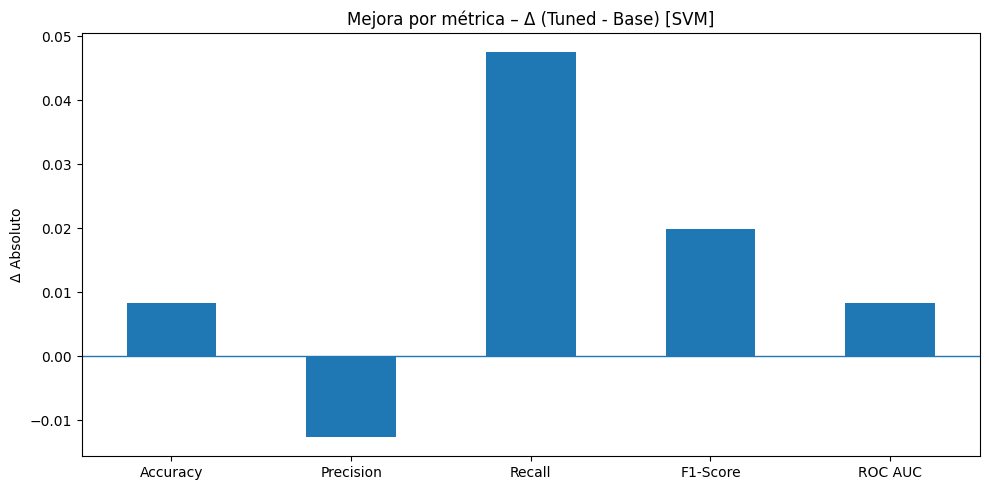

In [ ]:
## COMPARATIVA SVC ANTES Y DESPUÉS DE AJUSTE

df_compare = pd.DataFrame([results["SVM"], Result_tuned_SVC], index=["Antes (Base SVM)", "Después (SVM Tuned)"]).T
df_compare["Δ (Tuned - Base)"] = df_compare["Después (SVM Tuned)"] - df_compare["Antes (Base SVM)"]

print("\n📊 Comparación de métricas (TEST):")
display(df_compare.sort_values("Δ (Tuned - Base)", ascending=False))

# 4) Gráficos: barras comparativas y barras de Δ
plt.figure(figsize=(12, 6))
df_compare[["Antes (Base SVM)", "Después (SVM Tuned)"]].plot(kind="bar")
plt.title("Comparación de Métricas – SVM Base vs Tuned (TEST)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
df_compare["Δ (Tuned - Base)"].plot(kind="bar")
plt.title("Mejora por métrica – Δ (Tuned - Base) [SVM]")
plt.ylabel("Δ Absoluto")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


SVM tuneado es mejor para nuestro objetivo si priorizamops capturar phishing (recall/F1), con un costo mínimo en precisión.

#### Implementación de XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report)

# peso de clase para desbalance
pos_ratio = y_train.mean()
scale_pos_weight = (1 - pos_ratio) / pos_ratio if pos_ratio > 0 else 1.0
print(f"scale_pos_weight sugerido: {scale_pos_weight:.2f} (pos_ratio={pos_ratio:.3f})")

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb)
])

param_grid = {
    'clf__n_estimators': [600],          # Nº de árboles (rondas de boosting). Más árboles ↑ capacidad, ↑ tiempo; se controla con learning_rate/early stopping.
    'clf__learning_rate': [0.1],         # Tasa de aprendizaje (shrinkage). Más bajo → pasos más chicos, necesita más árboles pero suele generalizar mejor.
    'clf__max_depth': [5],               # Profundidad máxima de cada árbol. ↑ profundidad capta interacciones complejas pero puede sobreajustar.
    'clf__min_child_weight': [1],     # Mínima suma de pesos de instancia (Hessian) en un nodo hijo. ↑ valor → splits más conservadores (menos overfitting).
    'clf__subsample': [0.8, 1.0],        # Fracción de filas muestreadas por árbol. <1 añade aleatoriedad, reduce varianza/overfitting.
    'clf__colsample_bytree': [0.5, 0.7, 0.8],  # Fracción de features muestreadas por árbol. <1 decorrelaciona árboles y reduce overfitting.
    'clf__gamma': [0]                 # Mínima reducción de pérdida para hacer un split (min_split_loss). ↑ gamma → modelo más conservador (pruning).
}


grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Buscando mejores hiperparámetros XGBoost…")
grid_xgb.fit(X_train, y_train)

print("\nMejores params (según F1):")
print(grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

Result_tuned_XGB =  {"Accuracy":  accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC AUC":   roc_auc_score(y_test, y_prob_tuned)
}

# --- Métricas en TEST ---
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- XGBoost en TEST ---")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1:      {f1_score(y_test, y_pred):.4f}")
print(f"Recall:  {recall_score(y_test, y_pred):.4f}")
print(f"Precision:{precision_score(y_test, y_pred):.4f}")
print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


scale_pos_weight sugerido: 2.00 (pos_ratio=0.333)
Buscando mejores hiperparámetros XGBoost…
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Mejores params (según F1):
{'clf__colsample_bytree': 0.5, 'clf__gamma': 0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 1, 'clf__n_estimators': 600, 'clf__subsample': 0.8}

--- XGBoost en TEST ---
ROC AUC: 0.9517
F1:      0.8372
Recall:  0.8675
Precision:0.8089
Accuracy:0.8875

Classification Report:
              precision    recall  f1-score   support

           0     0.9313    0.8975    0.9141       800
           1     0.8089    0.8675    0.8372       400

    accuracy                         0.8875      1200
   macro avg     0.8701    0.8825    0.8756      1200
weighted avg     0.8905    0.8875    0.8884      1200



Realizamos una comparación de los valores obtenidos por cada modelo.

Resumen de Resultados de Modelos de Clasificación:


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
4,XGB,0.883333,0.838542,0.8050,0.821429,0.945369
2,Random Forest,0.880000,0.861582,0.7625,0.809019,0.945092
3,SVM,0.875000,0.851124,0.7575,0.801587,0.936991
1,Decision Tree,0.859167,0.803150,0.7650,0.783611,0.851964
0,Logistic Regression,0.853333,0.820000,0.7175,0.765333,0.921113


<Figure size 1400x800 with 0 Axes>

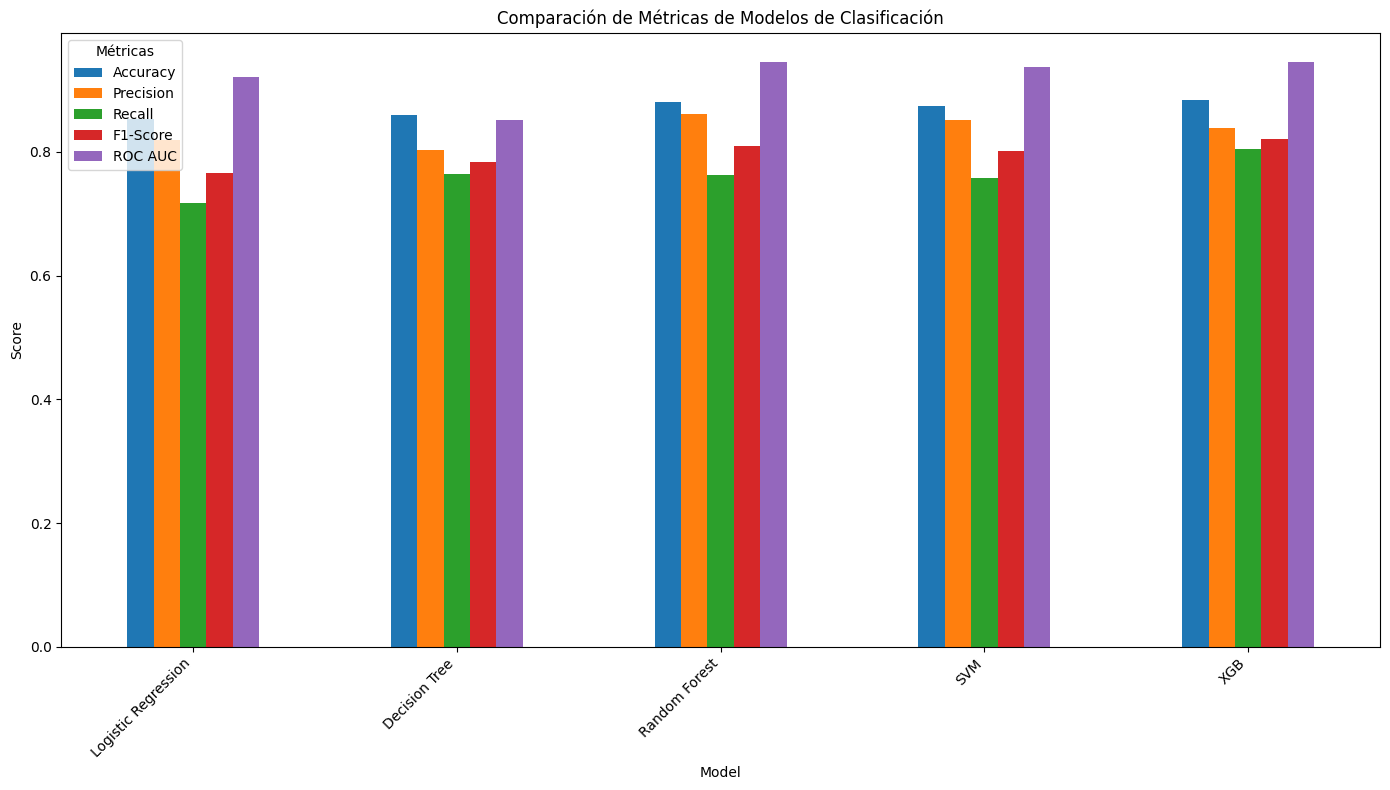

In [ ]:
summary_data.append({
  "Model": "XGB",
  "Accuracy": Result_tuned_XGB["Accuracy"],
  "Precision": Result_tuned_XGB["Precision"],
  "Recall": Result_tuned_XGB["Recall"],
  "F1-Score": Result_tuned_XGB["F1-Score"],
  "ROC AUC": Result_tuned_XGB["ROC AUC"]
})

df_results_summary = pd.DataFrame(summary_data)

print("Resumen de Resultados de Modelos de Clasificación:")
display(df_results_summary.sort_values(by="F1-Score", ascending=False))

# Visualizar las métricas clave
plt.figure(figsize=(14, 8))
df_results_summary.set_index("Model").plot(kind='bar', figsize=(14, 8))
plt.title("Comparación de Métricas de Modelos de Clasificación")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Métricas")
plt.tight_layout()
plt.show()

 En este set, **XGBoost** ofrece el **mejor balance global** (mayor *F1* y *Recall*, *Accuracy* más alta y *ROC AUC* ligeramente superior), por lo que es el candidato principal para **capturar más phishing**; **Random Forest** queda segundo con la **mejor Precisión**, útil si se quiere **reducir falsos positivos**; SVM rinde similar a RF pero por debajo en *ROC AUC*, y *Decision Tree* / *LogReg* quedan rezagados.

### 3.2. Análisis No Supervisado: Clustering y Detección de Anomalías

Exploraremos si las técnicas no supervisadas pueden ayudarnos a identificar patrones o grupos que se relacionen con la etiqueta de phishing.

#### Preparación de Datos para Análisis No Supervisado

Para técnicas como K-Means, es importante escalar los datos numéricos.

Para visualizar el clustering en 2D/3D comenzamos con un pipeline de preprocesamiento numérico que incluye imputación (para manejar faltantes) y escalado (para homogeneizar magnitudes).
Las variables categóricas pueden incorporarse mediante One-Hot Encoding; sin embargo, para una visualización inicial más simple y estable, usaremos solo las características numéricas escaladas. Esto reduce ruido y evita explosión de dimensionalidad.

In [ ]:
# Seleccionar solo las columnas numéricas para este análisis no supervisado inicial
X_numeric = df_master[numerical_features]

# Crear un pipeline para imputar y escalar los datos numéricos
numeric_pipeline_scaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Imputar valores faltantes con la mediana
    ('scaler', StandardScaler()) # Escalar los datos
])

# Aplicar el preprocesamiento a los datos numéricos
X_numeric_scaled = numeric_pipeline_scaled.fit_transform(X_numeric)

print("Primeras 5 filas de los datos numéricos escalados:")
print(X_numeric_scaled[:5])

Primeras 5 filas de los datos numéricos escalados:
[[-0.18808329 -0.63985531 -0.29172635 -0.21795679  0.          0.
  -0.21068086  0.17460668]
 [-0.18808329 -0.63985531 -0.29172635 -0.21795679  0.          0.
  -0.21068086  0.17460668]
 [-0.18808329  0.31283015 -0.29172635 -0.21795679  0.          0.
  -0.21068086  0.17460668]
 [-0.18808329  0.69390433 -0.29172635 -0.21795679  0.          0.
  -0.21068086 -0.29939952]
 [-0.18808329 -0.25878113 -0.29172635 -0.21795679  0.          0.
  -0.21068086 -1.97319376]]


#### Aplicación de K-Means Clustering

Aplicaremos K-Means para intentar encontrar grupos en los datos. Necesitamos determinar un número adecuado de clusters (k).

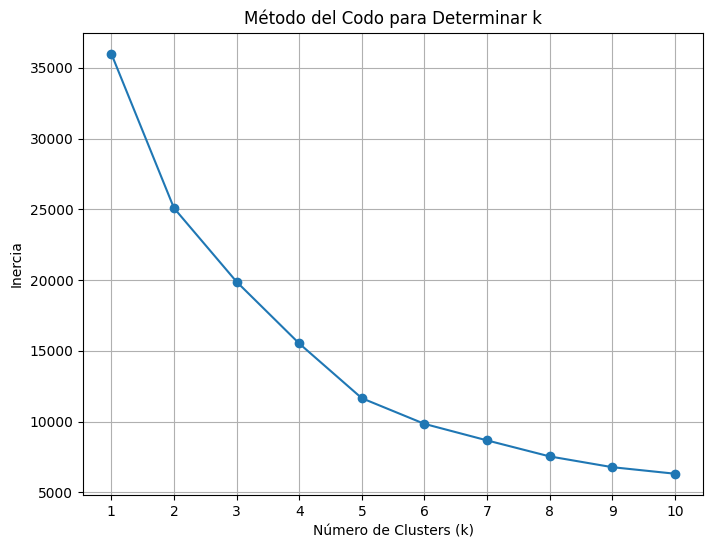

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # Para visualización en 2D

# Determinar el número óptimo de clusters (Método del Codo)
inertia = []
# Probamos diferentes valores de k (por ejemplo, de 1 a 10)
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(X_numeric_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Método del Codo para Determinar k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

A partir del **gráfico del codo** observamos un punto de inflexión claro que sugiere valores pequeños de **k**. Operativamente, tiene sentido evaluar **k=2** (dos grupos: *legítimo* vs. *phishing*) o **k=3** (tres grupos: *legítimo*, *phishing* y un posible segmento *desconocido/anómalo*).

Para este experimento seleccionamos **k=2** con el objetivo de verificar si la partición resultante **se alinea con la etiqueta `is_phishing`**. Esta elección facilita la interpretación inicial (comparando directamente con la clase binaria), y servirá como base para analizar métricas por cluster (p. ej., **tasa de phishing por cluster**) y la coherencia entre el *clustering* no supervisado y las etiquetas reales. Si detectamos mezcla significativa dentro de los clusters, reconsideraremos **k** (p. ej., **k=3**) para capturar un grupo intermedio/anómalo.



Distribución de los clusters:
cluster
0    5795
1     205
Name: count, dtype: int64

Relación entre Clusters y la etiqueta 'is_phishing':
is_phishing     0     1
cluster                
0            4000  1795
1               0   205


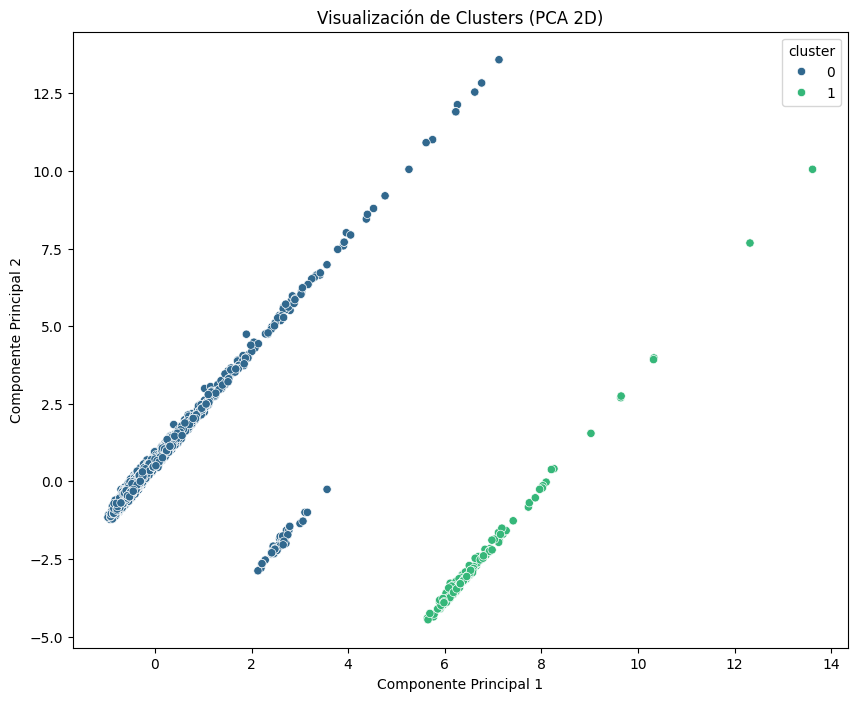

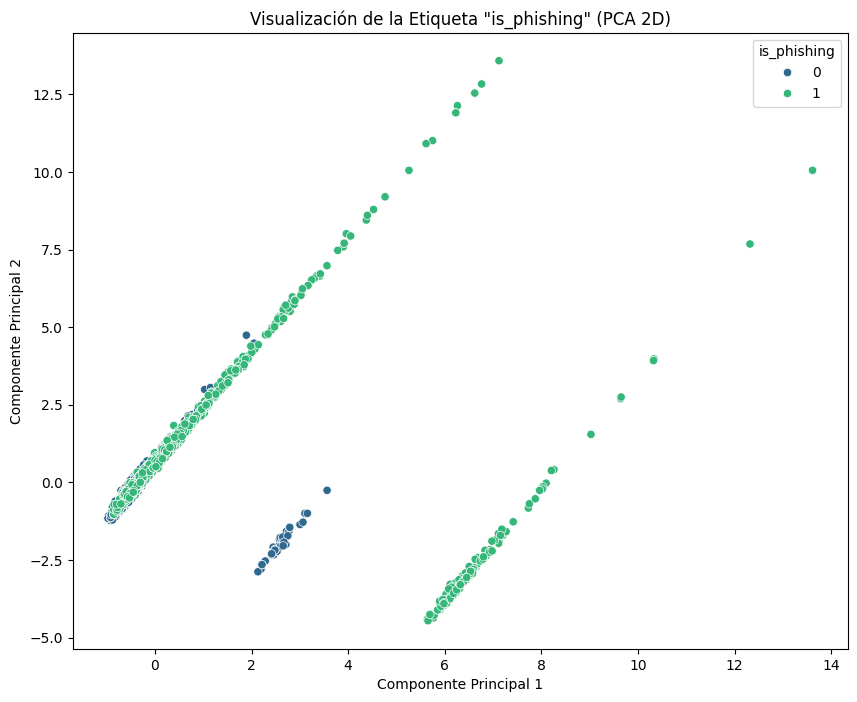

In [ ]:
optimal_k = 2 # Ajustar según el gráfico del codo

# Aplicar K-Means con el número óptimo de clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_numeric_scaled)

# Añadir las etiquetas de cluster al DataFrame original para el análisis
df_master_clustered = df_master.copy()
df_master_clustered['cluster'] = clusters

print("\nDistribución de los clusters:")
print(df_master_clustered['cluster'].value_counts())

# Analizar la relación entre los clusters y la etiqueta 'is_phishing'
print("\nRelación entre Clusters y la etiqueta 'is_phishing':")
print(pd.crosstab(df_master_clustered['cluster'], df_master_clustered['is_phishing']))

# Visualizar los clusters (usando PCA para reducir la dimensionalidad a 2D)
# Aplicar PCA a los datos numéricos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric_scaled)

# Añadir los componentes principales y las etiquetas de cluster al DataFrame para visualización
df_master_clustered['PCA1'] = X_pca[:, 0]
df_master_clustered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_master_clustered, x='PCA1', y='PCA2', hue='cluster', palette='viridis', legend='full')
plt.title('Visualización de Clusters (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Visualizar la etiqueta 'is_phishing' en el espacio PCA para comparación
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_master_clustered, x='PCA1', y='PCA2', hue='is_phishing', palette='viridis', legend='full')
plt.title('Visualización de la Etiqueta "is_phishing" (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

#### Detección de Anomalías (con Isolation Forest)

La detección de anomalías puede identificar sitios que son significativamente diferentes de la mayoría, lo cual podría ser útil para detectar nuevos ataques de phishing.

Aplicamos **Isolation Forest** sobre las **características numéricas escaladas** para identificar **outliers** (posibles URLs sospechosas/atípicas). Este algoritmo “aísla” observaciones mediante particiones aleatorias: los puntos raros suelen aislarse con **menos particiones**, por lo que reciben puntajes de anomalía más altos.

**Parámetros clave**

* **`contamination`**: proporción esperada de outliers en el conjunto. Úsalo para fijar el **umbral de decisión** interno. Debe basarse en conocimiento de dominio (p. ej., 5% si estimás que \~5% de los casos son anómalos).
* **`random_state`**: semilla para **reproducibilidad** de resultados.

**Procedimiento**

1. Entrenar el modelo sobre los **datos numéricos ya imputados y escalados**.
2. Obtener **predicciones** (`-1` = anómalo, `1` = normal) y/o **scores** de anomalía.
3. (Opcional) **Visualizar** en 2D (PCA/UMAP) coloreando por anómalo/normal para evaluar separabilidad.
4. **Cruzar** con la etiqueta `is_phishing` para medir coherencia: por ejemplo, tasa de phishing dentro del subconjunto anómalo vs. normal.
5. Ajustar **`contamination`** si hay exceso de falsos positivos/negativos respecto a lo esperado por el negocio.



Distribución de las etiquetas de anomalía (-1: Anomalía, 1: Normal):
anomaly
 1    5258
-1     742
Name: count, dtype: int64

Relación entre Anomalías detectadas y la etiqueta 'is_phishing':
is_phishing     0     1
anomaly                
-1            255   487
 1           3745  1513


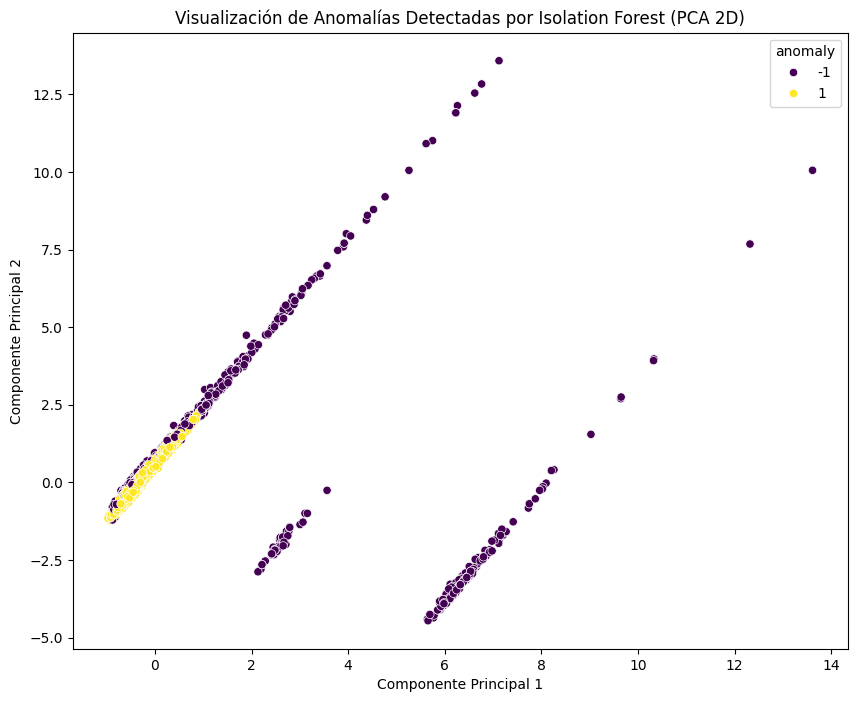

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination='auto', random_state=42) # 'auto' estima la proporción de outliers

# Entrenar el modelo de detección de anomalías
iso_forest.fit(X_numeric_scaled)

# Predecir las anomalías (-1 para outliers, 1 para inliers)
anomalies = iso_forest.predict(X_numeric_scaled)

# Añadir los resultados de la detección de anomalías al DataFrame
df_master_clustered['anomaly'] = anomalies

print("\nDistribución de las etiquetas de anomalía (-1: Anomalía, 1: Normal):")
print(df_master_clustered['anomaly'].value_counts())

# Analizar si las anomalías detectadas se corresponden con la etiqueta 'is_phishing'
print("\nRelación entre Anomalías detectadas y la etiqueta 'is_phishing':")
print(pd.crosstab(df_master_clustered['anomaly'], df_master_clustered['is_phishing']))

# Visualizar las anomalías en el espacio PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_master_clustered, x='PCA1', y='PCA2', hue='anomaly', palette='viridis', legend='full')
plt.title('Visualización de Anomalías Detectadas por Isolation Forest (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### 3.3. Selección del Modelo Final y Próximos Pasos

Basándonos en los resultados del análisis supervisado y no supervisado, seleccionaremos el modelo o enfoque más adecuado para la detección de sitios fraudulentos.

**Análisis de Resultados:**

*   **Modelos Supervisados:** Analizamos las métricas de rendimiento (Precision, Recall, F1-Score, ROC AUC) para determinar qué modelo clasifica mejor los sitios fraudulentos. Un alto Recall es crucial para minimizar los falsos negativos (sitios fraudulentos no detectados), mientras que la Precision ayuda a reducir los falsos positivos (sitios legítimos marcados como fraudulentos). El F1-Score y ROC AUC proporcionan un balance general del rendimiento. El ajuste de hiperparámetros puede mejorar aún más estos resultados.
*   **Análisis No Supervisado:** Observamos si las técnicas de clustering y detección de anomalías pueden identificar patrones o grupos que se alinean con la etiqueta de phishing. Si un cluster se compone predominantemente de sitios etiquetados como phishing, esto valida la relevancia de las características utilizadas y sugiere que los enfoques supervisados pueden ser efectivos. La detección de anomalías podría ser útil para identificar nuevos tipos de ataques que se desvíen de los patrones conocidos.

**Selección del Modelo:**

*   Se seleccionará el modelo supervisado que ofrezca el mejor balance de métricas, priorizando Recall y F1-Score para minimizar la pérdida de detección de sitios fraudulentos.
*   Los hallazgos del análisis no supervisado pueden complementar el enfoque supervisado, por ejemplo, informando la selección de características o identificando casos para una revisión manual.

**Próximos Pasos:**

1.  **Validación Final del Modelo:** Realizar una validación más rigurosa del modelo seleccionado en un conjunto de datos de validación independiente o mediante validación cruzada más exhaustiva.
2.  **Despliegue del Modelo:** Preparar el modelo seleccionado para su implementación en un entorno de producción, lo que podría implicar serializar el modelo entrenado y el pipeline de preprocesamiento.
3.  **Integración del Sistema:** Integrar el modelo de detección en un sistema más amplio que pueda recibir URLs, preprocesarlas, pasar la información al modelo y generar alertas o acciones basadas en la predicción.
4.  **Monitoreo y Retraining:** Establecer un proceso para monitorear continuamente el rendimiento del modelo en producción y retenerlo periódicamente con nuevos datos para adaptarse a la evolución de las técnicas de phishing.

### Conclusiones Entregable 3

En este entregable, hemos avanzado significativamente en la construcción del componente de detección de nuestro sistema:

*   Hemos preparado nuestro dataset maestro, manejando valores faltantes y codificando variables categóricas.
*   Hemos entrenado y evaluado varios modelos de clasificación supervisada, identificando cuáles ofrecen el mejor rendimiento según métricas clave para la detección de phishing. En base a este analisis, determinamos que el modelo que ofrece mejor Recall y F1-Score corresponde a XGBoost debido a sus parametros de regularización ya que permite que el modelo generalice mejor. Además incorpora parámetros para el manejo de desbalance de clases para evitar sesgo en la clase mayoritaria.
*   Hemos explorado técnicas de clustering y detección de anomalías para obtener una comprensión más profunda de la estructura de nuestros datos y la relación entre las características y la etiqueta de phishing.
*   Hemos definido los próximos pasos para la validación, despliegue, monitoreo y mantenimiento de nuestro modelo de detección de sitios fraudulentos.

El análisis confirma que es posible construir modelos efectivos para la detección de phishing utilizando las características extraídas y las técnicas de Machine Learning exploradas. La combinación de enfoques supervisados (para clasificar patrones conocidos) y no supervisados (para identificar posibles nuevas amenazas) proporciona una base sólida para un sistema de detección robusto.